# House Price Prediction

### Import the necessary libraries and load the dataset.

In [2]:
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats

In [3]:
train_df = pd.read_csv('Datasets/train_(2)_(1)_(1).csv')
test_df = pd.read_csv('Datasets/test_(2)_(1)_(1).csv')
avg_rent = pd.read_csv('Datasets/avg_rent_(1)_(1)_(1).csv')
city_dist = pd.read_csv('Datasets/dist_from_city_centre_(1).csv')

In [4]:
train_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
avg_rent.head()

,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [6]:
test_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
0,0,Super built-up Area,Ready To Move,Chamrajpet,2 BHK,NaN,650,1.0,1.0
1,1,Super built-up Area,Ready To Move,7th Phase JP Nagar,3 BHK,SrncyRe,1370,2.0,1.0
2,2,Super built-up Area,Ready To Move,Whitefield,3 BHK,AjhalNa,1725,3.0,2.0
3,3,Built-up Area,Ready To Move,Jalahalli,2 BHK,NaN,1000,2.0,0.0
4,4,Plot Area,Ready To Move,TC Palaya,1 Bedroom,NaN,1350,1.0,0.0


In [7]:
train_df.shape

(10656, 10)

In [8]:
avg_rent.shape

(157, 2)

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


##### We can observe that more features are object and some of the features have missing values.

In [10]:
train_df.describe()

,ID,bath,balcony,price
count,10656.000000,10591.000000,10152.000000,10656.000000
mean,5327.500000,2.690586,1.581757,112.214256
std,3076.266568,1.352403,0.821357,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


In [11]:
train_df.isna().sum()

ID                 0
area_type          0
availability       0
location           1
size              14
society         4428
total_sqft         0
bath              65
balcony          504
price              0
dtype: int64

In [12]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

##### Will take a copy of the dataframe to avoid any changes to the original dataframe.

In [13]:
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

### Data Cleaning and Preprocessing

In [14]:
train_df_copy['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'ArariGo', 'Vicony ', 'Srhemay'],
      dtype=object)

In [15]:
train_df_copy['society'].nunique()

2364

##### Will drop the 'ID' column as it does not contribute to the prediction. 

##### Also 'society' column has a lot of unique values which may not contribute to the prediction. Hence dropping that too.

In [16]:
train_df_copy['area_type'].value_counts()

area_type
Super built-up  Area    7009
Built-up  Area          1927
Plot  Area              1651
Carpet  Area              69
Name: count, dtype: int64

In [17]:
train_df_copy['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr'], dtype=object)

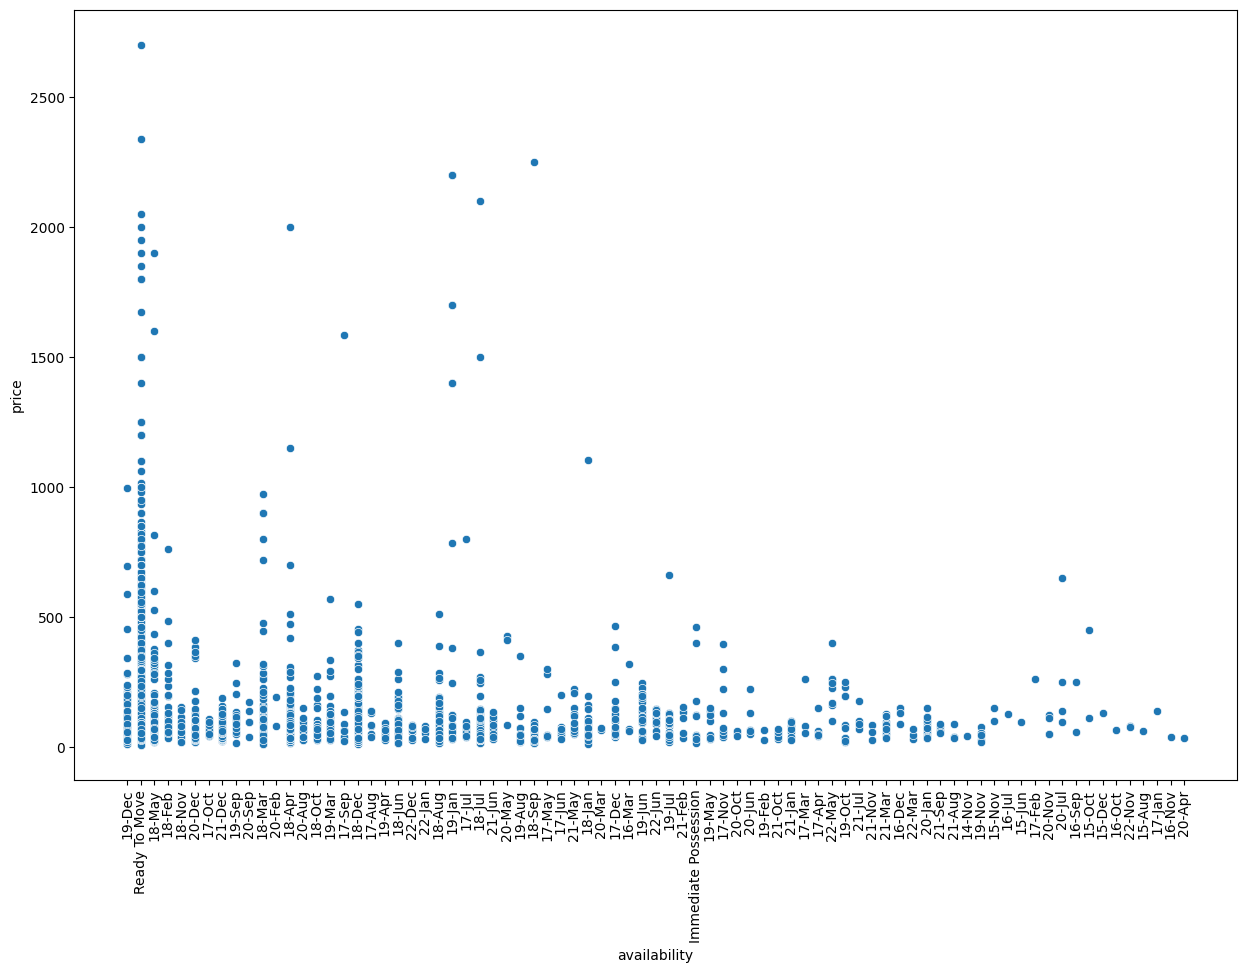

In [18]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='availability', y='price', data=train_df)
plt.xticks(rotation=90)
plt.show()

##### Will remove this 'availability' features 

In [19]:
train_df_copy['location'].unique().tolist()

['Electronic City Phase II',
 'Chikka Tirupathi',
 'Uttarahalli',
 'Lingadheeranahalli',
 'Kothanur',
 'Whitefield',
 'Old Airport Road',
 'Rajaji Nagar',
 'Marathahalli',
 'Gandhi Bazar',
 '7th Phase JP Nagar',
 'Gottigere',
 'Sarjapur',
 'Mysore Road',
 'Bisuvanahalli',
 'Raja Rajeshwari Nagar',
 'Ramakrishnappa Layout',
 'Manayata Tech Park',
 'Kengeri',
 'Binny Pete',
 'Thanisandra',
 'Bellandur',
 ' Thanisandra',
 'Mangammanapalya',
 'Electronic City',
 'Ramagondanahalli',
 'Yelahanka',
 'Hebbal',
 'Kasturi Nagar',
 'Kanakpura Road',
 'Electronics City Phase 1',
 'Kundalahalli',
 'Chikkalasandra',
 'Murugeshpalya',
 'Sarjapur  Road',
 'Ganga Nagar',
 'HSR Layout',
 'Doddathoguru',
 'KR Puram',
 'Himagiri Meadows',
 'Adarsh Nagar',
 'Bhoganhalli',
 'Lakshminarayana Pura',
 'Begur Road',
 'Devanahalli',
 'Govindaraja Nagar Ward',
 'Tharabanahalli',
 'Varthur',
 'Bommanahalli',
 'Gunjur',
 'Devarachikkanahalli',
 'Double Road',
 'Hegde Nagar',
 'Haralur Road',
 'Hennur Road',
 'Kotha

In [20]:
train_df_copy['location'].nunique()

1197

##### Here some values are having spelling issue which we will correct it.

In [21]:
train_df_copy['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK'], dtype=object)

##### Will make 1 RK as 0 and will strip the value to remove string from the column, and none values to Mode.

In [22]:
train_df_copy['total_sqft']

0        1056
1        2600
2        1440
3        1521
4        1200
         ... 
10651    1200
10652    1260
10653    1092
10654     827
10655    1357
Name: total_sqft, Length: 10656, dtype: object

##### 'total_sqft' column is in object. Will check if there are any non-numeric values.

In [23]:
def check_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [24]:
train_df_copy[~train_df_copy['total_sqft'].apply(lambda x : check_float(x))]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130',
       '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091',
       '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455',
       '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter',
       '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273',
       '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933',
       '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards',
       '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49',
       '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360',
       '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804',
       '1255 - 1863', '1300 - 1405', '1

##### We can see that many values are having ranges and some values are having units. We will take range values as average of the range, and unit values will be None. 

In [25]:
train_df_copy['bath'].value_counts()

bath
2.0     5530
3.0     2608
4.0      991
1.0      639
5.0      411
6.0      216
7.0       86
8.0       48
9.0       35
10.0      11
12.0       7
16.0       2
11.0       2
27.0       1
14.0       1
40.0       1
15.0       1
13.0       1
Name: count, dtype: int64

Now we will do all above steps in function for better reusability.

In [26]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

In [27]:
train_df.columns

Index(['ID', 'area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [28]:
soc = train_df_copy.society.value_counts()

In [29]:
soc[soc>20].count()

30

In [30]:
train_df_copy.drop(columns='ID').duplicated().sum()

345

In [31]:
train_df_copy.drop(columns='ID').drop_duplicates(inplace=True)

In [32]:
del_col = ['ID','availability', 'balcony']

In [33]:
def get_size_value(x):
    if pd.isna(x):
        return x
    return x.split()[0]

In [34]:
def get_sq_ft(x):
    if check_float(x):
        return x
    else:
        val = x.split(' - ')
        if len(val) == 2:
            return (float(val[0])+float(val[1]))/2
        return None

In [35]:
def check_insance(x):
    if isinstance(x, list):
        return any
    elif isinstance(x, tuple):
        return all


In [36]:
def loc_clean(x):
    x = x.lower()
    x = re.sub(r'[, !&. /-]', '', x)
    return x

In [37]:
loc = {
    '1st Block HRBR Layout' : ('hrbr', '1stblock'),
    '2nd Block Hrbr Layout' : ('hrbr', '2ndblock'),
    '3rd Block Hrbr Layout' : ('hrbr', '3rdblock'),
    'HRBR Layout' : ('hrbr',),
    'Vijayanagar' : ['vijayanagar', 'vijaynagar'],
    '1st Block Jayanagar' : ('jayanagar', '1stblock'),
    '2nd Block Jayanagar' : ('jayanagar', '2ndblock'),
    '4th T block Jayanagar' : ('jayanagar', '4thblock'),
    '7th Block Jayanagar' : ('jayanagar', '7thblock'),
    '9th Block Jayanagar' : ('jayanagar', '9thblock'),
    'Jayanagar' : ('jayanagar',),
    '1st Block Koramangala' : ('koramangala', '1stblock'),
    '4th Block Koramangala' : ('koramangala', '4thblock'),
    '6th block Koramangala' : ('koramangala', '6thblock'),
    '8th block Koramangala' : ('koramangala', '8thblock'),
    'Koramangala' : ('koramangala',),
    '1st Phase JP Nagar' : ('jpnagar', '1stphase'),
    '2nd Phase JP Nagar' : ('jpnagar', '2ndphase'),
    '4th Phase JP Nagar' : ('jpnagar', '4thphase'),
    '5th Phase JP Nagar' : ('jpnagar', '5thphase'),
    '6th Phase JP Nagar' : ('jpnagar', '6thphase'),
    '7th Phase JP Nagar' : ('jpnagar', '7thphase'),
    '8th Phase JP Nagar' : ('jpnagar', '8thphase'),
    '9th Phase JP Nagar' : ('jpnagar', '9thphase'),
    'JP Nagar' : ('jpnagar',),
    'Indira Nagar' : ('indiranagar',),
    '2nd Phase Judicial Layout' : ('judicial', '2ndphase'),
    'Judicial Layout' : ('judicial',),
    '2nd Stage Nagarbhavi' : ('nagarbhavi', '2ndstage'),
    'Nagarbhavi' : ('nagarbhavi',),
    'Banashankari' : ('banashankari',),
    '5th Block Hbr Layout' : ('hbrlayout', '5thblock'),
    'HBR Layout' : ('hbrlayout',),
    'Mahalakshmi Puram' : ('mahalakshmi',),
    'Lakshminarayana Pura' : ['lakshminarayanapura', 'lakshmipura'],
    'Lakshmi Layout' : ('lakshmi',),
    'A Narayanapura' : ('anarayanapura',),
    'B Narayanapura' : ('bnarayanapura',),
    'Narayanapura' : ('narayanapura',),
    'Abbigere' : ('abbigere',),
    'AECS Layout' : ('aecslayout',),
    'AGS Layout' : ('agslayout',),
    'Akshayanagara East' : ('akshayanagaraeast',),
    'Akshaya Nagar' : ['akshaya', 'akshya'],
    'Ambalipura' : ['ambalipura', 'amblipura'],
    'Ambedkar Nagar' : ('ambedkar',),
    'Amruthahalli' : ('amruthahalli',),
    'Anand Nagar' : ('anandnagar',),
    'Anandapura' : ('anandapura',),
    'Ananth Nagar' : ('ananthnagar',),
    'Anekal' : ('anekal',) ,
    'Anjanapura' : ('anjanapura',) ,
    'Ardendale' : ('ardendale',) ,
    'Arekere' : ('arekere',) ,
    'Ashwath Nagar' : ('ashwathnagar',) ,
    'Sarjapur' : ('sarjapur',) ,
    'Attibele' : ('attibele',) ,
    'Attur Layout' : ('attur',) ,
    'Austin Town' : ('austintown',) ,
    'Babusapalaya' : ('babusapalaya',) ,
    'Badavala Nagar' : ('badavalanagar',) ,
    'Bagalakunte' : ('bagalakunte',) ,
    'Bagalur' : ('bagalur',) ,
    'Balagere' : ('balagere',) ,
    'Banagiri Nagar' : ('banagirinagar',) ,
    'Hormavu' : ['horamavu', 'hormavu'] ,
    'Banaswadi' : ('banaswadi',) ,
    'Banjara Layout' : ('banjaralayout',) ,
    'Bannerghatta Road' : ('bannerghattaroad',) ,
    'Bannerghatta' : ('bannerghatta',) ,
    'Basapura' : ('basapura',) ,
    'Basavanagara' : ['basavanagar', 'basavanagara'] ,
    'Basavanapura' : ('basavanapura',) ,
    'Basavangudi' : ('basavangudi',) ,
    'Basaveshwara Nagar' : ['basaveshwaranagar', 'basaveswarnagar'] ,
    'Basaveshwara Nagar Yelahanka' : ('basaveshwaranagaryelahanka',) ,
    'Battarahalli' : ['battarahalli', 'bhattarahalli'] ,
    'Begur' : ('begur',) ,
    'Begur Road' : ('begurroad',) ,
    'Belathur' : ['belathur', 'belatur'] ,
    'Bellandur' : ('bellandur',) ,
    'BEML Layout' : ('bemllayout',) ,
    'Benson Town' : ('bensontown',) ,
    'Bharathi Nagar' : ['bharathinagar', 'bharathnagar', 'bharatnagar'] ,
    'Bhoganhalli' : ('bhoganhalli',) ,
    'Bhuvaneshwari Nagar' : ['bhuvaneshwarinagar', 'bhuvaneswarinagar'] ,
    'Billekahalli' : ('billekahalli',) ,
    'Binny Pete' : ('binnypete',) ,
    'Bisuvanahalli' : ('bisuvanahalli',) ,
    'Bommanahalli' : ('bommanahalli',) ,
    'Doddabommasandra' : ('doddabommasandra',) ,
    'Bommasandra' : ('bommasandra',) ,
    'Bommasandra Industrial Area' : ('bommasandraindustrialarea',) ,
    'Bommenahalli' : ('bommenahalli',) ,
    'Brookefield' : ('brookefield',) ,
    'BTM 1st Stage' : ('btm', '1st') ,
    'BTM 2nd Stage' : ('btm', '2nd') ,
    'BTM Layout' : ('btm',) ,
    'Budigere' : ('budigere',) ,
    'Byadarahalli' : ('byadarahalli',) ,
    'Byatarayanapura' : ('byatarayanapura',) ,
    'Byrasandra' : ('byrasandra',) ,
    'Cambridge Layout' : ('cambridgelayout',) ,
    'Canara Bank Colony' : ('canarabank',) ,
    'Chamrajpet' : ('chamrajpet',) ,
    'Chandapura' : ('chandapura',) ,
    'Chandra Layout' : ('chandralayout',) ,
    'Channasandra' : ('channasandra',) ,
    'Chelekare' : ('chelekare',) ,
    'Chennammana Kere' : ('chennammanakere',) ,
    'Chikkalasandra' : ('chikkalasandra',) ,
    'Choodasandra' : ('choodasandra',) ,
    'Cooke Town' : ('cooketown',) ,
    'Cottonpet' : ('cottonpet',) ,
    'Cox Town' : ('coxtown',) ,
    'Cunningham Road' : ('cunninghamroad',) ,
    'CV Raman Nagar' : ('cvramannagar',) ,
    'Dairy Circle' : ('dairycircle',) ,
    'Dasanapura' : ('dasanapura',) ,
    'Dasarahalli' : ('dasarahalli',) ,
    'Devanahalli' : ('devanahalli',) ,
    'Devarachikkanahalli' : ('devarachikkanahalli',) ,
    'Doddaballapur' : ('doddaballapur',) ,
    'Doddakallasandra' : ('doddakallasandra',) ,
    'Doddanekundi' : ['doddanekundi', 'doddanekkundi'] ,
    'Doddathoguru' : ('thoguru',) ,
    'Dodsworth Layout' : ('dodsworthlayout',) ,
    'Dollars Colony' : ('dollars',) ,
    'Domlur' : ('domlur',) ,
    'Dommasandra' : ('dommasandra',) ,
    'Ejipura' : ('ejipura',) ,
    'Electronic City Phase II' : ('electronic', 'phaseii') ,
    'Electronics City Phase 1' : ('electronic', 'phase1') ,
    'Electronic City' : ('electronic',) ,
    'EPIP Zone' : ('epip',) ,
    'Frazer Town' : ['frazertown', 'frasertown'] ,
    'Ganga Nagar' : ('ganganagar',) ,
    'Garudachar Palya' : ('garudacharpalya',) ,
    'Giri Nagar' : ('girinagar',) ,
    'GM Palaya' : ('gmpalaya',) ,
    'Gollahalli' : ('gollahalli',) ,
    'Gollarapalya Hosahalli' : ('gollarapalyahosahalli',) ,
    'Gopalkrishna Nagar' : ('gopalkrishnanagar',) ,
    'Gottigere' : ('gottigere',) ,
    'Govindpura' : ['govindpura', 'govindapura'] ,
    'Green Glen Layout' : ('greenglenlayout',) ,
    'Gubbalala' : ('gubbalala',) ,
    'Gunjur Palya' : ('gunjurpalya',) ,
    'Gunjur' : ('gunjur',) ,
    'HAL 2nd Stage' : ('hal2ndstage',) ,
    'Haralur Road' : ('haralurroad',) ,
    'Harlur' : ('harlur',) ,
    'Harsha Layout' : ('harshalayout',) ,
    'Hebbal Kempapura' : ('hebbalkempapura',) ,
    'Hebbal' : ('hebbal',) ,
    'Hegde Nagar' : ('hegdenagar',) ,
    'Hennur Bande' : ('hennurbande',) ,
    'Hennur Gardens' : ('hennurgardens',) ,
    'Hennur Road' : ('hennurroad',) ,
    'Hennur' : ('hennur',) ,
    'Herohalli' : ('herohalli',) ,
    'Hessarghatta' : ('hessarghatta',) ,
    'Hiremath Layout' : ('hiremathlayout',) ,
    'HMT Layout' : ('hmtlayout',) ,
    'Hongasandra' : ('hongasandra',) ,
    'Hoodi' : ('hoodi',) ,
    'Hosa Road' : ('hosaroad',) ,
    'Hosahalli Extension' : ('hosahalli',) ,
    'Hoskote' : ('hoskote',) ,
    'Hosur Road' : ('hosur',) ,
    'Hoysalanagar' : ('hoysalanagar',) ,
    'Sector 1 HSR Layout' : ('hsrlayout', '1') ,
    'Sector 2 HSR Layout' : ('hsrlayout', '2') ,
    'Sector 6 HSR Layout' : ('hsrlayout', '6') ,
    'Sector 7 HSR Layout' : ('hsrlayout', '7') ,
    'HSR Layout' : ('hsrlayout',) ,
    'Hulimavu' : ('hulimavu',) ,
    'Huskur' : ('huskur',) ,
    'Iblur Village' : ('iblurvillage',) ,
    'Immadihalli' : ('immadihalli',) ,
    'ISRO Layout' : ('isrolayout',) ,
    'ITI Layout' : ('itilayout',) ,
    'ITPL' : ('itpl',) ,
    'Ittamadu' : ('ittamadu',) ,
    'Jakkasandra Extension' : ('jakkasandraextension',) ,
    'Jakkur Plantation' : ('jakkurplantation',) ,
    'Jakkuru Layout' : ('jakkurulayout',) ,
    'Jakkur' : ('jakkur',) ,
    'Jalahalli East' : ('jalahallieast',) ,
    'Jalahalli West' : ('jalahalliwest',) ,
    'Jalahalli' : ('jalahalli',) ,
    'JCR Layout' : ('jcrlayout',) ,
    'Jeevan bima nagar' : ('jeevanbimanagar',) ,
    'Jigani' : ('jigani',) ,
    'Jnanabharathi Layout' : ('jnanabharathilayout',) ,
    'Kacharakanahalli' : ('kacharakanahalli',) ,
    'Kada Agrahara' : ('kadaagrahara',) ,
    'Kadabagere' : ('kadabagere',) ,
    'Kadubeesanahalli' : ('kadubeesanahalli',) ,
    'Kadugodi' : ('kadugodi',) ,
    'Kadugondanahalli' : ('kadugondanahalli',) ,
    'Kaggadasapura' : ('kaggadasapura',) ,
    'Kaggalipura' : ('kaggalipura',) ,
    'Kaikondrahalli' : ('kaikondrahalli',) ,
    'Kalena Agrahara' : ('kalenaagrahara',) ,
    'Kalkere' : ('kalkere',) ,
    'Kallumantapa' : ('kallumantapa',) ,
    'Kalyan nagar' : ('kalyannagar',) ,
    'Kamakshipalya' : ('kamakshipalya',) ,
    'Kamala Nagar' : ('kamalanagar',) ,
    'Kambipura' : ('kambipura',) ,
    'Kammagondahalli' : ('kammagondahalli',) ,
    'Kammanahalli' : ('kammanahalli',) ,
    'Kammasandra' : ('kammasandra',) ,
    'Kanaka Nagar' : ('kanakanagar',) ,
    'Kanakpura Road' : ['kanakpuraroad', 'kanakapuraroad', 'kanakapuramainroad'] ,
    'Kanakapura' : ('kanakapura',) ,
    'Kannamangala' : ('kannamangala',) ,
    'Karuna Nagar' : ('karunanagar',) ,
    'Kasavanhalli' : ('kasavanhalli',) ,
    'Kasturi Nagar' : ('kasturinagar',) ,
    'Kathriguppe' : ['kathriguppe', 'kathreguppe'] ,
    'Kattigenahalli' : ('kattigenahalli',) ,
    'Kaval Byrasandra' : ('kavalbyrasandra',) ,
    'Kaverappa Layout' : ('kaverappalayout',) ,
    'Kenchenahalli' : ['kenchenahalli', 'kenchenhalli'] ,
    'Kengeri Satellite Town' : ('kengerisatellitetown',) ,
    'Kengeri' : ('kengeri',) ,
    'Kereguddadahalli' : ('kereguddadahalli',) ,
    'Keshava Nagar' : ('keshavanagar',) ,
    'Kirloskar Layout' : ('kirloskarlayout',) ,
    'Kodathi' : ('kodathi',) ,
    'Kodbisanhalli' : ('kodbisanhalli',) ,
    'Kodichikkanahalli' : ('kodichikkanahalli',) ,
    'Kodigehalli' : ['kodigehaali', 'kodigehalli'] ,
    'Kodihalli' : ('kodihalli',) ,
    'Kogilu' : ('kogilu',) ,
    'Konanakunte' : ('konanakunte',) ,
    'Kothanur' : ['kothannur', 'kothanur'] ,
    'KR Garden' : ('krgarden',) ,
    'KR Puram' : ('krpuram',) ,
    'Kudlu Gate' : ('kudlugate',) ,
    'KUDLU MAIN ROAD' : ('kudlumainroad',) ,
    'Kudlu' : ('kudlu',) ,
    'Kumara Park' : ('kumarapark',) ,
    'Kumarapalli' : ('kumarapalli',) ,
    'Kumaraswami Layout' : ('kumaraswamilayout',) ,
    'Kundalahalli Colony' : ('kundalahallicolony',) ,
    'Kundalahalli' : ('kundalahalli',) ,
    'Kurubarahalli' : ('kurubarahalli',) ,
    'Kuvempu Nagar' : ('kuvempunagar',) ,
    'Laggere' : ('laggere',) ,
    'Lake City' : ('lakecity',) ,
    'Langford Town' : ('langfordtown',) ,
    'Lavakusha Nagar' : ('lavakushanagar',) ,
    'Lavelle Road' : ('lavelleroad',) ,
    'Laxmi Sagar Layout' : ('laxmisagarlayout',) ,
    'LB Shastri Nagar' : ('lbshastrinagar',) ,
    'Lingadheeranahalli' : ('lingadheeranahalli',) ,
    'Lingarajapuram' : ('lingarajapuram',) ,
    'Madiwala' : ('madiwala',) ,
    'Magadi Road' : ('magadiroad',) ,
    'Mahadevpura' : ('mahadevpura',) ,
    'Maithri Layout' : ('maithrilayout',) ,
    'Mallasandra' : ('mallasandra',) ,
    'Mallathahalli' : ('mallathahalli',) ,
    'Malleshpalya' : ('malleshpalya',) ,
    'Malleshwaram' : ('malleshwaram',) ,
    'Manayata Tech Park' : ('manayatatechpark',) ,
    'Manjunath Nagar' : ('manjunathnagar',) ,
    'Maragondanahalli' : ('maragondanahalli',) ,
    'Marathahalli' : ('marathahalli',) ,
    'Margondanahalli' : ('margondanahalli',) ,
    'Marsur' : ('marsur',) ,
    'Maruthi Nagar' : ('maruthinagar',) ,
    'Maruthi Sevanagar' : ('maruthisevanagar',) ,
    'Mathikere' : ('mathikere',) ,
    'MCECHS  layout' : ('mcechslayout',) ,
    'Medahalli' : ('medahalli',) ,
    'Meenakunte' : ('meenakunte',) ,
    'Mico Layout' : ('micolayout',) ,
    'Motappa Layout' : ('motappalayout',) ,
    'MS Pallya' : ('mspallya',) ,
    'Munivenkatppa Layout' : ('munivenkatppalayout',) ,
    'Munnekollal' : ('munnekollal',) ,
    'Murugeshpalya' : ('murugeshpalya',) ,
    'Mylasandra' : ('mylasandra',) ,
    'Mysore Highway' : ('mysorehighway',) ,
    'Mysore Road' : ('mysoreroad',) ,
    'Nagadevanahalli' : ('nagadevanahalli',) ,
    'Naganathapura' : ('naganathapura',) ,
    'Nagappa Reddy Layout' : ('nagappareddylayout',) ,
    'Nagaraja Garden' : ('nagarajagarden',) ,
    'Nagasandra' : ('nagasandra',) ,
    'Nagashetty Halli' : ('nagashettyhalli',) ,
    'Nagavarapalya' : ('nagavarapalya',) ,
    'Nagavara' : ('nagavara',) ,
    'Nagawara Junction' : ('nagawarajunction',) ,
    'Nagondanahalli' : ('nagondanahalli',) ,
    'Nallurhalli' : ('nallurhalli',) ,
    'Nayandanahalli' : ('nayandanahalli',) ,
    'Neeladri Nagar' : ('neeladrinagar',) ,
    'Nehru Nagar' : ('nehrunagar',) ,
    'Nelamangala' : ('nelamangala',) ,
    'New Gurappana Palya' : ('newgurappanapalya',) ,
    'New Thippasandra' : ('newthippasandra',) ,
    'Ngef Layout' : ('ngeflayout',) ,
    'NGR Layout' : ('ngrlayout',) ,
    'NRI Layout' : ('nrilayout',) ,
    'NS Palya' : ('nspalya',) ,
    'Old Airport Road' : ('oldairportroad',) ,
    'OLd Gurappanapalya' : ('oldgurappanapalya',) ,
    'Old Madras Road' : ('oldmadrasroad',) ,
    'OMBR Layout' : ('ombrlayout',) ,
    'Outer Ring Road East' : ('outerringroadeast',) ,
    'Padmanabhanagar' : ('padmanabhanagar',) ,
    'Pai Layout' : ('pailayout',) ,
    'Panathur' : ('panathur',) ,
    'Parappana Agrahara' : ('parappanaagrahara',) ,
    'Pattanagere' : ('pattanagere',) ,
    'Pattandur Agrahara' : ('pattanduragrahara',) ,
    'Peenya' : ('peenya',) ,
    'Poorna Pragna Layout' : ('poornapragnalayout',) ,
    'Prithvi Layout' : ('prithvilayout',) ,
    'Puttanahalli' : ('puttanahalli',) ,
    'R.T. Nagar' : ('rtnagar',) ,
    'Rachenahalli' : ('rachenahalli',) ,
    'Raghuvanahalli' : ('raghuvanahalli',) ,
    'Raja Rajeshwari Nagar 5th Stage' : ('rajarajeshwarinagar5thstage',) ,
    'Raja Rajeshwari Nagar' : ('rajarajeshwarinagar',) ,
    'Rajaji Nagar' : ('rajajinagar',) ,
    'Rajiv Gandhi Nagar' : ('rajivgandhinagar',) ,
    'Rajiv Nagar' : ('rajivnagar',) ,
    'Ramagondanahalli' : ('ramagondanahalli',) ,
    'Ramakrishnappa Layout' : ('ramakrishnappalayout',) ,
    'Ramamurthy Nagar' : ('ramamurthynagar',) ,
    'Ramamurthy Nagar Extension' : ('ramamurthynagarextension',) ,
    'Ramanjaneyanagar' : ('ramanjaneyanagar',) ,
    'Rayasandra' : ('rayasandra',) ,
    'Reliaable Tranquil Layout' : ('reliaabletranquillayout',) ,
    'Richards Town' : ('richardstown',) ,
    'Richmond Town' : ('richmondtown',) ,
    'RMV Extension' : ('rmv',) ,
    'RMV 2nd Stage' : ('rmv2ndstage',) ,
    'Roopena Agrahara' : ('roopenaagrahara',) ,
    'Rustam Bagh Layout' : ('rustambaghlayout',) ,
    'RWF West Colony' : ('rwfwestcolony',) ,
    'Sadashiva Nagar' : ('sadashivanagar',) ,
    'Sahakara Nagar' : ('sahakaranagar',) ,
    'Sai Gardens' : ('saigardens',) ,
    'Samethanahalli' : ('samethanahalli',) ,
    'Sanjay nagar' : ('sanjaynagar',) ,
    'Sarakki Nagar' : ('sarakkinagar',) ,
    'Sathya Sai Layout' : ('sathyasailayout',) ,
    'Seegehalli' : ('seegehalli',) ,
    'Seetharampalya' : ('seetharampalya',) ,
    'Shampura' : ('shampura',) ,
    'Shankarapuram' : ('shankarapuram',) ,
    'Shanthala Nagar' : ('shanthalanagar',) ,
    'Shanti Nagar' : ('shantinagar',) ,
    'Shantiniketan Layout' : ('shantiniketanlayout',) ,
    'Shikaripalya' : ('shikaripalya',) ,
    'Shivaji Nagar' : ('shivajinagar',) ,
    'Siddapura' : ('siddapura',) ,
    'Sidedahalli' : ('sidedahalli',) ,
    'Silk Board' : ('silkboard',) ,
    'Singapura Village' : ('singapuravillage',) ,
    'Singasandra' : ('singasandra',) ,
    'Singena Agrahara' : ('singenaagrahara',) ,
    'Somasundara Palya' : ('somasundarapalya',) ,
    'Sompura' : ('sompura',) ,
    'Sonnenahalli' : ('sonnenahalli',) ,
    'Srinivasa Nagar' : ('srinivasanagar',) ,
    'Srirampura' : ('srirampura',) ,
    'Srirampuram' : ('srirampuram',) ,
    'Stage-4 Bommanahalli' : ('stage4bommanahalli',) ,
    'Subramanyapura' : ('subramanyapura',) ,
    'Suddaguntepalya' : ('suddaguntepalya',) ,
    'Sultan Palaya' : ('sultanpalaya',) ,
    'Sunkadakatte' : ('sunkadakatte',) ,
    'Suraksha Nagar' : ('surakshanagar',) ,
    'Tala Cauvery Layout' : ('talacauverylayout',) ,
    'Talaghattapura' : ('talaghattapura',) ,
    'Tata Nagar' : ('tatanagar',) ,
    'TC Palaya' : ['tcpalaya', 'tcpalya'] ,
    'Tejaswini Nagar' : ('tejaswininagar',) ,
    'Thanisandra main road' : ('thanisandramainroad',) ,
    'Thanisandra' : ('thanisandra',) ,
    'Thigalarapalya' : ('thigalarapalya',) ,
    'Thirumenahalli' : ('thirumenahalli',) ,
    'Thubarahalli' : ('thubarahalli',) ,
    'Thyagaraja Nagar' : ('thyagarajanagar',) ,
    'Tindlu' : ('tindlu',) ,
    'Tumkur Road' : ('tumkurroad',) ,
    'Udaya Nagar' : ('udayanagar',) ,
    'Udayapur Village' : ('udayapurvillage',) ,
    'Ulsoor' : ('ulsoor',) ,
    'Upkar Layout' : ('upkarlayout',) ,
    'Uttarahalli' : ('uttarahalli',) ,
    'Vajarahalli' : ('vajarahalli',) ,
    'Varanasi' : ('varanasi',) ,
    'Varsova Layout' : ('varsovalayout',) ,
    'Varthur Road' : ('varthurroad',) ,
    'Varthur' : ('varthur',) ,
    'Vasanth nagar' : ('vasanthnagar',) ,
    'Vasantha Vallabha Nagar' : ('vasanthavallabhanagar',) ,
    'Vasanthapura' : ['vasanthapura', 'vasanthpura'] ,
    'Venkatapura' : ['venkatapura', 'venkateshpuram'] ,
    'VGP Layout' : ('vgplayout',) ,
    'Victoria Layout' : ('victorialayout',) ,
    'Vidyaranyapura' : ('vidyaranyapura',) ,
    'Vignana Nagar' : ('vignananagar',) ,
    'Vijaya Bank Layout' : ('vijayabank',) ,
    'Virat Nagar' : ('viratnagar',) ,
    'Vishveshwarya Layout' : ('vishveshwaryalayout',) ,
    'Vishwanatha Nagenahalli' : ('vishwanathanagenahalli',) ,
    'Vishwapriya Layout' : ['vishwapriyalayout', 'vishwapriyanagar'] ,
    'Vittasandra' : ('vittasandra',) ,
    'Volagerekallahalli' : ('volagerekallahalli',) ,
    'Whitefield' : ('white',) ,
    'Wilson Garden' : ('wilsongarden',) ,
    'Yelachenahalli' : ('yelachenahalli',) ,
    'Yelahanka New Town' : ('yelahankanewtown',) ,
    'Yelahanka' : ('yelahanka',) ,
    'Yelenahalli' : ('yelenahalli',) ,
    'Yemlur' : ('yemlur',) ,
    'Yeshwanthpur' : ('yeshwanthpur',) ,
    'Sarjapur  Road' : ('sarjapurroad',) ,
    'Horamavu Agara' : ('horamavuagara',) ,
    'Hosakerehalli' : ('hosakerehalli',) ,
    'Dodda Nekkundi' : ('doddanekkundi',) ,
    'Horamavu Banaswadi' : ('horamavubanaswadi',) ,
    'Banashankari Stage III' : ('banashankaristageiii',) ,
    'Kothannur' : ('kothannur',) ,
    'Sarjapura - Attibele Road' : ('sarjapuraattibeleroad',) ,
    'Chikka Tirupathi' : ('chikkatirupathi',) ,
    'Banashankari Stage II' : ('banashankaristageii',) ,
    'Banashankari Stage VI' : ('banashankaristagevi',) ,
    'Mahalakshmi Layout' : ('mahalakshmilayout',) ,
    'Chikkabanavar' : ('chikkabanavar',) ,
    'Kodigehaali' : ('kodigehaali',) ,
    'Banashankari Stage V' : ('banashankaristagev',) ,
    'Akshaya Vana' : ('akshayavana',) ,
    'Sarjapur Road,' : ('sarjapurroad',) ,
    'Dodda Nekkundi Extension' : ('doddanekkundiextension',) ,
    'Hoodi Circle,' : ('hoodicircle',) ,
    'Doctors Layout' : ('doctorslayout',) ,
    'Doddakammanahalli' : ('doddakammanahalli',) ,
    'Cholanayakanahalli' : ('cholanayakanahalli',) ,
    'Defence Colony' : ('defencecolony',) ,
    'Green View Layout' : ('greenviewlayout',) ,
    'Ambedkar Colony' : ('ambedkarcolony',) ,
    'Bank Of Baroda Colony' : ('bankofbarodacolony',) ,
    'HOSUR MAIN ROAD' : ('hosurmainroad',) ,
    'Channasandra Layout' : ('channasandralayout',) ,
    'Ashirvad Colony' : ('ashirvadcolony',) ,
    'Dodda Banaswadi' : ('doddabanaswadi',) ,
    'Devasthanagalu' : ('devasthanagalu',) ,
    'Amblipura' : ('amblipura',) ,
    'Ashwathnagar' : ('ashwathnagar',) ,
    'Abbaiah Reddy Layout' : ('abbaiahreddylayout',) ,
    'Shree Ananth Nagar Layout' : ('shreeananthnagarlayout',) ,
    'Byrathi Village' : ('byrathivillage',) ,
    'Devarabeesana Halli' : ('devarabeesanahalli',) ,
    'Doddanakundi Industrial Area 2' : ('doddanakundiindustrialarea2',) ,
    'Doddakannelli' : ('doddakannelli',) ,
    'Bileshivale' : ('bileshivale',) ,
    'Gopalapura' : ('gopalapura',) ,
    'Avalahalli' : ('avalahalli',) ,
    'Akshya Nagar' : ('akshyanagar',) ,
    '1st Stage Indira Nagar' : ('1ststageindiranagar',) ,
    'Amruthnagar' : ('amruthnagar',) ,
    'Carmelaram' : ('carmelaram',) ,
    'Coconut Grove Layout' : ('coconutgrovelayout',) ,
    'Off Sarjapur Road,' : ('offsarjapurroad',) ,
    'Doopanahalli' : ('doopanahalli',) ,
    'Doddabanahalli' : ('doddabanahalli',) ,
    '3rd Block Banashankari' : ('3rdblockbanashankari',) ,
    'Chikkadunnasandra' : ('chikkadunnasandra',) ,
    'Bellari Road' : ('bellariroad',) ,
    'Devi Nagar' : ('devinagar',) ,
    'Vishwapriya Nagar' : ('vishwapriyanagar',) ,
    'Byagadadhenahalli' : ('byagadadhenahalli',) ,
    'Chinnapanahalli' : ('chinnapanahalli',) ,
    'Doddagubbi' : ('doddagubbi',) ,
    'Geddalahalli' : ('geddalahalli',) ,
    'tc.palya' : ('tc.palya',) ,
    'Glass Factory Layout' : ('glassfactorylayout',) ,
    'Judicial Layout, Kanakapura Road,' : ('judiciallayout', 'kanakapuraroad',) ,
    'Chikkathoguru' : ('chikkathoguru',) ,
    'BEL Road' : ('belroad',) ,
    'Brooke Bond First Cross' : ('brookebondfirstcross',) ,
    'Bikasipura' : ('bikasipura',) ,
    'Alfa Garden Layout' : ('alfagardenlayout',) ,
    'AMS Layout' : ('amslayout',) ,
    'Basavanna Nagar' : ('basavannanagar',) ,
    'Konanakunte Cross' : ('konanakuntecross',) ,
    'Chennappa Layout' : ('chennappalayout',) ,
    'Gowdanapalya' : ('gowdanapalya',) ,
    'BSM Extension' : ('bsmextension',) ,
}

In [38]:
train_df_copy['location']

0              Electronic City Phase II
1                      Chikka Tirupathi
2                           Uttarahalli
3                    Lingadheeranahalli
4                              Kothanur
                      ...              
10651                Parappana Agrahara
10652                       Bhoganhalli
10653    Doddanakundi Industrial Area 2
10654                Kachanayakanahalli
10655                Horamavu Banaswadi
Name: location, Length: 10656, dtype: object

In [39]:
train_df_copy.dropna(subset='location', inplace=True)

In [40]:
def reuse_func(x):
    df = x.drop(columns=del_col, errors='ignore')

    df['size'] = df['size'].apply(get_size_value)

    df['size'] = df['size'].astype('float')

    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    df['total_sqft'] = df['total_sqft'].astype('float')

    # df['availability'] = df['availability'].apply(lambda x : 'Dates' if x not in ('Ready To Move', 'Immediate Possession') else x)

    df['location'] = df['location'].apply(loc_clean)

    for val in loc:
        search_terms = loc[val] 
        mask = df['location'].apply(
            lambda x: check_insance(search_terms)(term in str(x) for term in search_terms)
        )   
        df.loc[mask, 'location'] = val

    df['dist_from_city'] = df['location'].map(city_dist.set_index('location')['dist_from_city'])
    
    # loc_count = df['location'].value_counts()
    # df['location'] = df['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=20] else x)

    return df

In [41]:
train_df_copy = reuse_func(train_df_copy)
test_df_copy = reuse_func(test_df_copy)

In [42]:
train_df_copy.dropna(subset='size', inplace=True)

In [43]:
location_price_map = train_df_copy.groupby('location')['price'].median()
q1 = location_price_map.quantile(0.33)
q2 = location_price_map.quantile(0.66)

overall_median_price = location_price_map.median()

In [44]:
def categorize_location_price(location):
    # Find the median price for this location from our map.
    # .get() is crucial: it uses 'overall_median_price' if a location is not in the map
    # (e.g., a new location in the test set)
    median_price = location_price_map.get(location, overall_median_price)
    
    if median_price < q1:
        return 'low'
    elif median_price < q2:
        return 'mid'
    else:
        return 'expensive'

train_df_copy['area_price_tier'] = train_df_copy['location'].apply(categorize_location_price)
test_df_copy['area_price_tier'] = test_df_copy['location'].apply(categorize_location_price)


<Axes: xlabel='area_price_tier', ylabel='Count'>

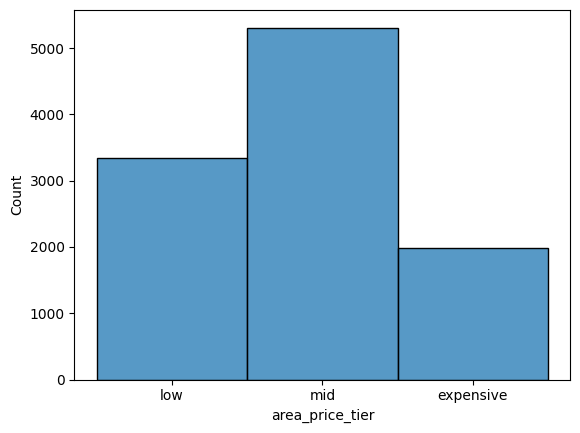

In [45]:
sns.histplot(train_df_copy['area_price_tier'])

In [46]:
loc_count = train_df_copy['location'].value_counts()
train_df_copy['location'] = train_df_copy['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=10] else x)

In [47]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10641 entries, 0 to 10655
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_type        10641 non-null  object 
 1   location         10641 non-null  object 
 2   size             10641 non-null  float64
 3   society          6216 non-null   object 
 4   total_sqft       10601 non-null  float64
 5   bath             10590 non-null  float64
 6   price            10641 non-null  float64
 7   dist_from_city   9859 non-null   float64
 8   area_price_tier  10641 non-null  object 
dtypes: float64(5), object(4)
memory usage: 831.3+ KB


In [48]:
avg_loc = train_df_copy.groupby('location')['total_sqft'].median()

In [49]:
def fill_val(x):
    df = x.copy()
    size_mode = df['size'].mode()[0]
    df['size'] = df['size'].fillna(size_mode)

    df['bath'] = df['bath'].fillna(df['size'])

    df['total_sqft'] = df['total_sqft'].fillna(df['location'].map(avg_loc))

    total_sqft_median = df['total_sqft'].median()
    df['total_sqft'] = df['total_sqft'].fillna(total_sqft_median)

    df.loc[df['dist_from_city'] > 20, 'dist_from_city'] = 20

    dist_from_city_median = df['dist_from_city'].median()
    df['dist_from_city'] = df['dist_from_city'].fillna(dist_from_city_median)

    return df

In [50]:
train_df_copy = fill_val(train_df_copy)
test_df_copy = fill_val(test_df_copy)

In [51]:
soc_count = train_df_copy['society'].value_counts()
train_df_copy['society'] = train_df_copy['society'].apply(lambda x: 'NoSociety' if x in soc_count[soc_count<=15] or pd.isna(x) else x)

In [52]:
test_df_copy.loc[~test_df_copy['location'].isin(train_df_copy['location']), 'location'] = 'Other'
test_df_copy.loc[~test_df_copy['society'].isin(train_df_copy['society']), 'society'] = 'NoSociety'

In [53]:
train_df_copy.society.value_counts()

society
NoSociety    9338
GrrvaGr        70
PrarePa        58
Prtates        52
Prtanha        45
GMown E        45
Sryalan        45
Prityel        42
Prarkun        41
Bhmesy         39
Dhalsh         38
PrityTr        37
IBityin        35
Soresea        33
SNnia E        30
Rosha I        30
Adeatlm        27
Bhe 2ko        27
SunceEs        26
SNity S        26
Soitya         25
DLhtsnd        24
Prlla C        23
Raard B        23
MenueNo        23
RothaVa        23
JRrnauv        22
Puachal        22
GoAirej        21
Brnia G        21
PuandHi        21
Sodgere        20
Prncyrn        20
ViistLa        19
Soazak         19
Dieldli        19
Shitt S        19
DLhtsan        18
Brway G        18
Magiaya        18
RInceeg        18
Soiewre        18
PhestOn        18
Itelaa         18
PueraRi        18
Eladero        17
Jaades         16
PualeSk        16
Name: count, dtype: int64

In [54]:
train_df_copy.isna().sum()

area_type          0
location           0
size               0
society            0
total_sqft         0
bath               0
price              0
dist_from_city     0
area_price_tier    0
dtype: int64

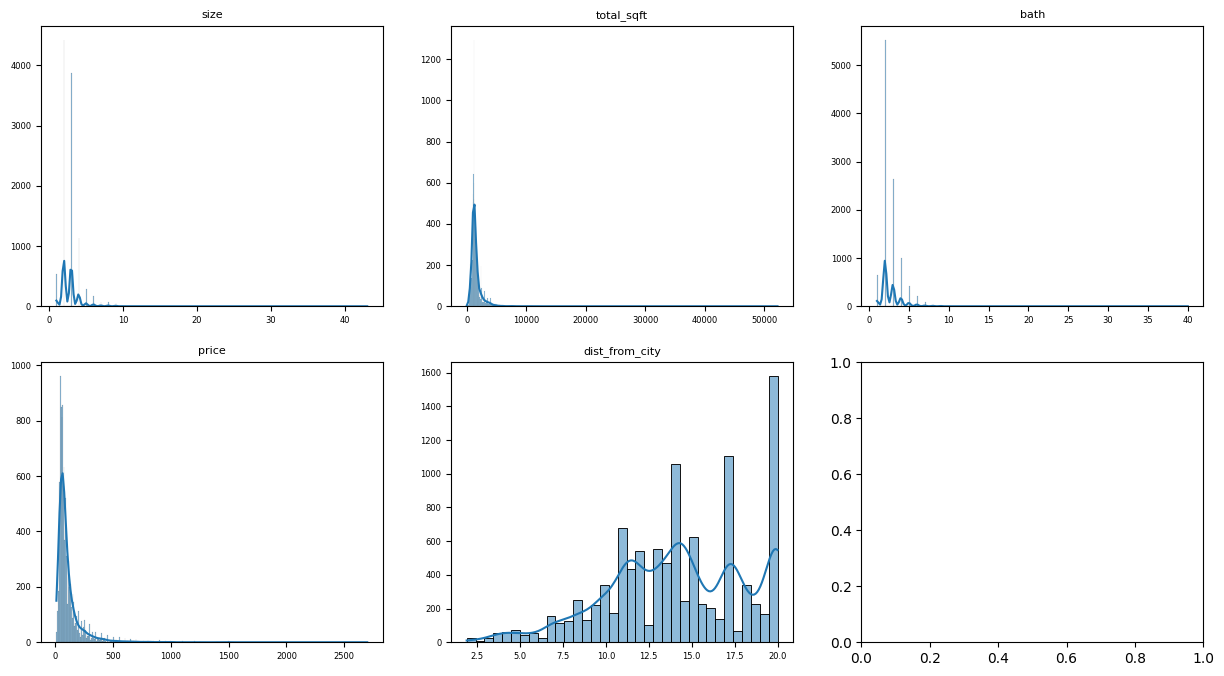

In [55]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

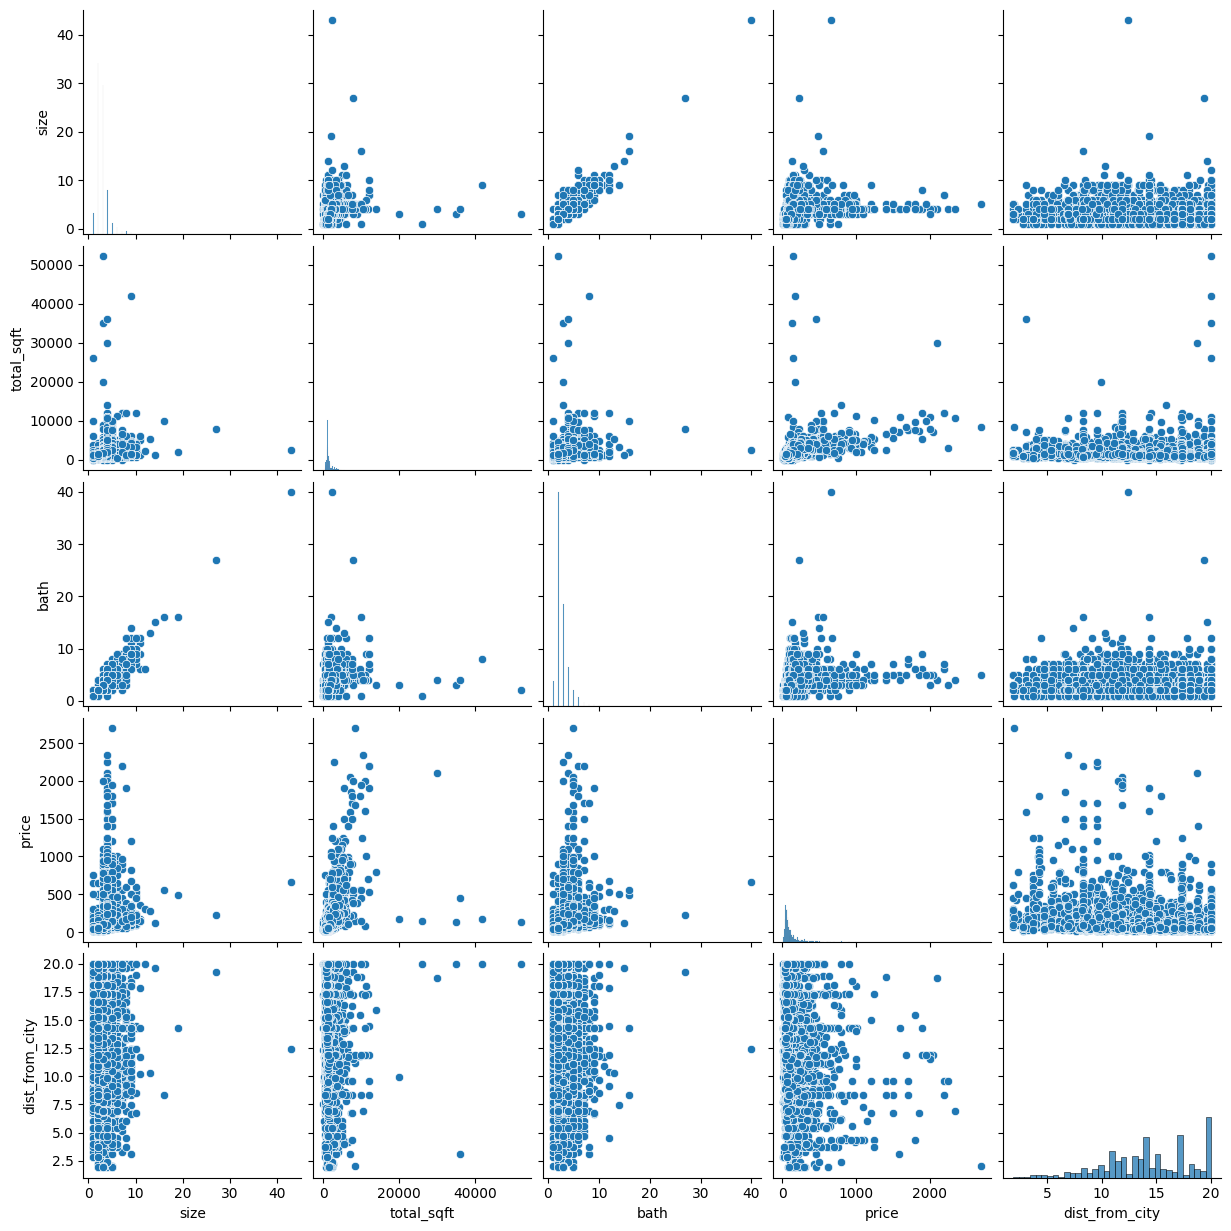

In [56]:
sns.pairplot(train_df_copy)

<Axes: xlabel='price', ylabel='Count'>

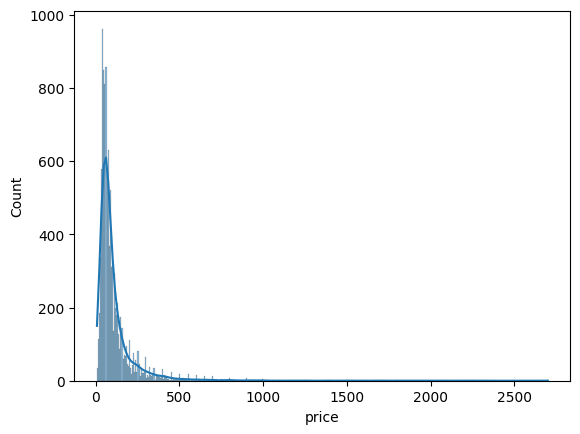

In [57]:
sns.histplot(data = train_df_copy, x = 'price', kde=True)

In [58]:
train_df_copy.shape

(10641, 9)

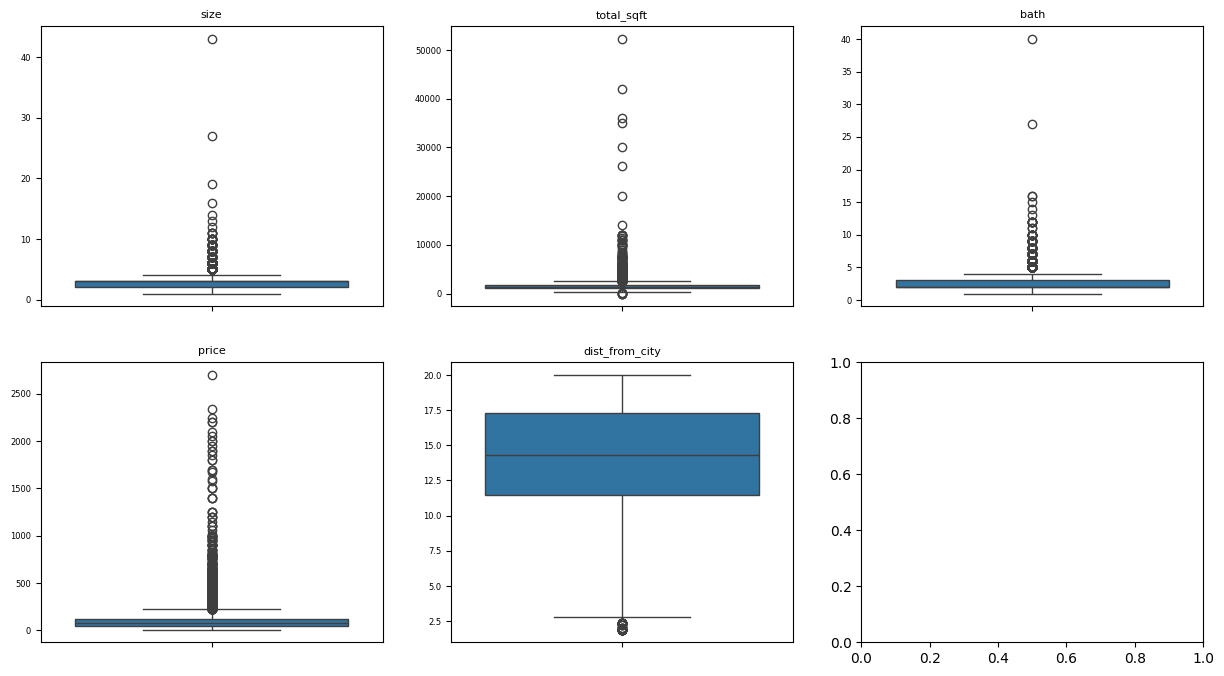

In [59]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [60]:
train_df_copy['price_per_sqft'] = train_df_copy['price']/train_df_copy['total_sqft']

In [61]:
train_df_copy['price_per_size'] = train_df_copy['price']/train_df_copy['size']

In [62]:
train_df_copy['sqft_per_size'] = train_df_copy['total_sqft']/train_df_copy['size']

In [63]:
test_df_copy['sqft_per_size'] = test_df_copy['total_sqft']/test_df_copy['size']

In [64]:
train_df_copy['price_per_size'].describe()

count    10641.000000
mean        38.019412
std         35.887374
min          3.333333
25%         21.666667
50%         29.000000
75%         41.250000
max        750.000000
Name: price_per_size, dtype: float64

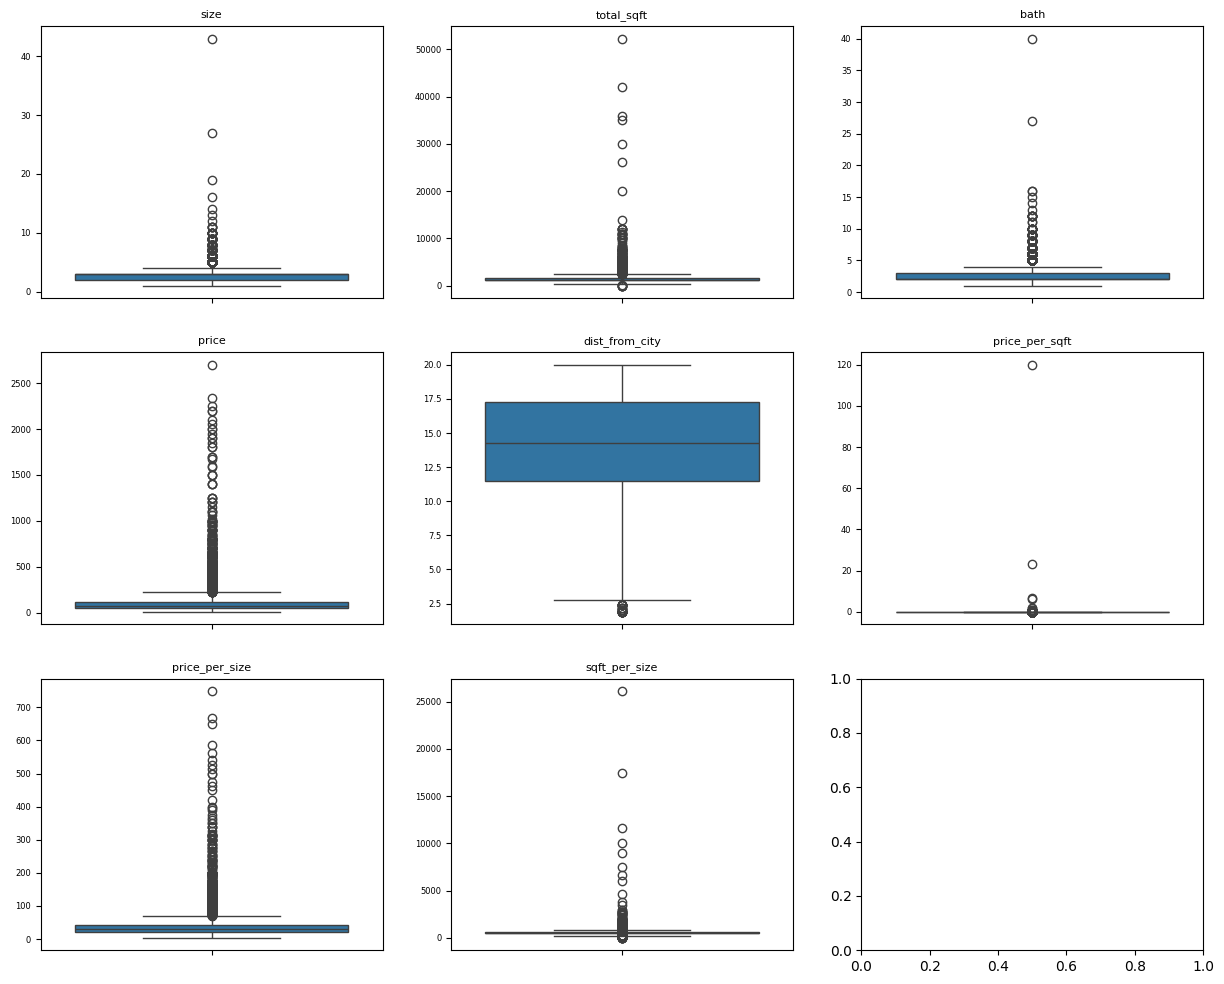

In [65]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

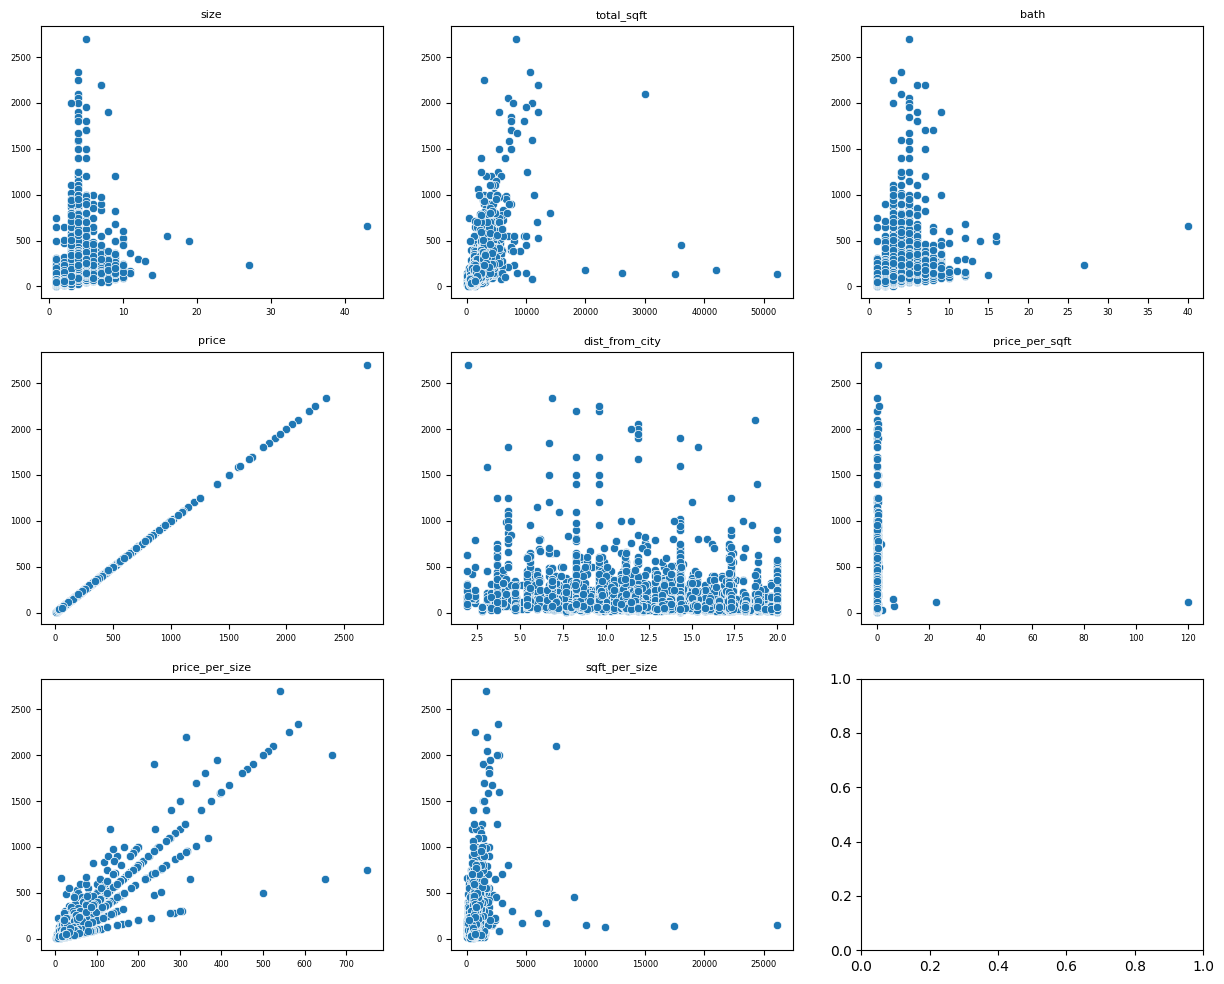

In [66]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [67]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city', 'area_price_tier', 'price_per_sqft',
       'price_per_size', 'sqft_per_size'],
      dtype='object')

In [68]:
train_df_copy['total_sqft'].describe()

count    10641.000000
mean      1557.815576
std       1271.757811
min          1.000000
25%       1100.000000
50%       1272.000000
75%       1674.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [69]:
train_df_copy['size'].value_counts()

size
2.0     4427
3.0     3870
4.0     1137
1.0      536
5.0      282
6.0      175
7.0       77
8.0       68
9.0       48
10.0      10
11.0       4
27.0       1
19.0       1
16.0       1
43.0       1
14.0       1
12.0       1
13.0       1
Name: count, dtype: int64

In [70]:
train_df_copy = train_df_copy[train_df_copy['size']<9]

In [71]:
train_df_copy.shape

(10572, 12)

In [72]:
train_df_copy['size'].value_counts()

size
2.0    4427
3.0    3870
4.0    1137
1.0     536
5.0     282
6.0     175
7.0      77
8.0      68
Name: count, dtype: int64

In [73]:
train_df_copy = train_df_copy[train_df_copy['bath'] < train_df_copy['size']+2]

In [74]:
loc_max = train_df_copy.groupby('location')['price_per_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < (train_df_copy['location'].map(loc_max))]

In [75]:
def remove_location_outliers(x):
    low_sz = x['price_per_size'].quantile(0.005)
    high_sz = x['price_per_size'].quantile(0.995)

    low_sqft = x['price_per_sqft'].quantile(0.005)
    high_sqft = x['price_per_sqft'].quantile(0.995)

    low_sqft_sz = x['sqft_per_size'].quantile(0.005)
    high_sqft_sz = x['sqft_per_size'].quantile(0.995)

    # Apply the filters all at once
    filtered_x = x[
        # (x['price_per_size'] > low_sz) & (x['price_per_size'] < high_sz) &
        (x['price_per_sqft'] > low_sqft) & (x['price_per_sqft'] < high_sqft)
        # & (x['sqft_per_size'] > low_sqft_sz) & (x['sqft_per_size'] < high_sqft_sz) 
    ]
    
    return filtered_x


In [76]:
# train_df_copy = train_df_copy.groupby('location').apply(remove_location_outliers).reset_index(drop=True)

In [77]:
low_sz = train_df_copy['price_per_size'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['price_per_size'] > low_sz]

low_sqft = train_df_copy['price_per_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] > low_sqft]

# low_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.003)
# train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] > low_sqft_sz]

low_sqft_total = train_df_copy['total_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] > low_sqft_total]

high_sqft = train_df_copy['price_per_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < high_sqft]

# high_sz = train_df_copy['price_per_size'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['price_per_size'] < high_sz]

# high_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] < high_sqft_sz]

high_sqft_total = train_df_copy['total_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] < high_sqft_total]

# high_price = train_df_copy['price'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['price'] < high_price]

In [78]:
train_df_copy.shape

(10058, 12)

In [79]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city', 'area_price_tier', 'price_per_sqft',
       'price_per_size', 'sqft_per_size'],
      dtype='object')

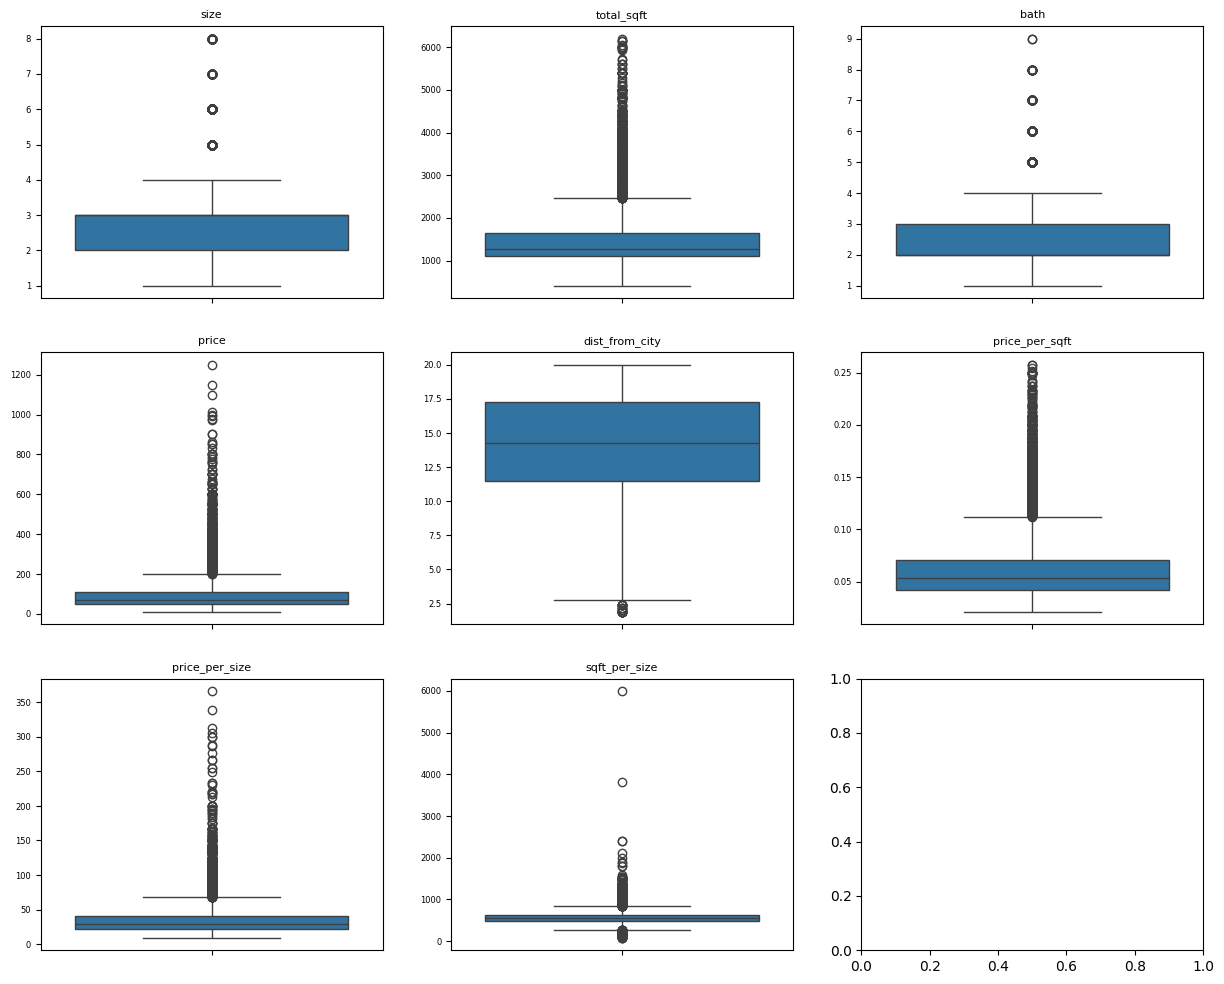

In [80]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [81]:
train_df_copy.drop(columns=['price_per_sqft', 'price_per_size', 'sqft_per_size'], inplace=True)

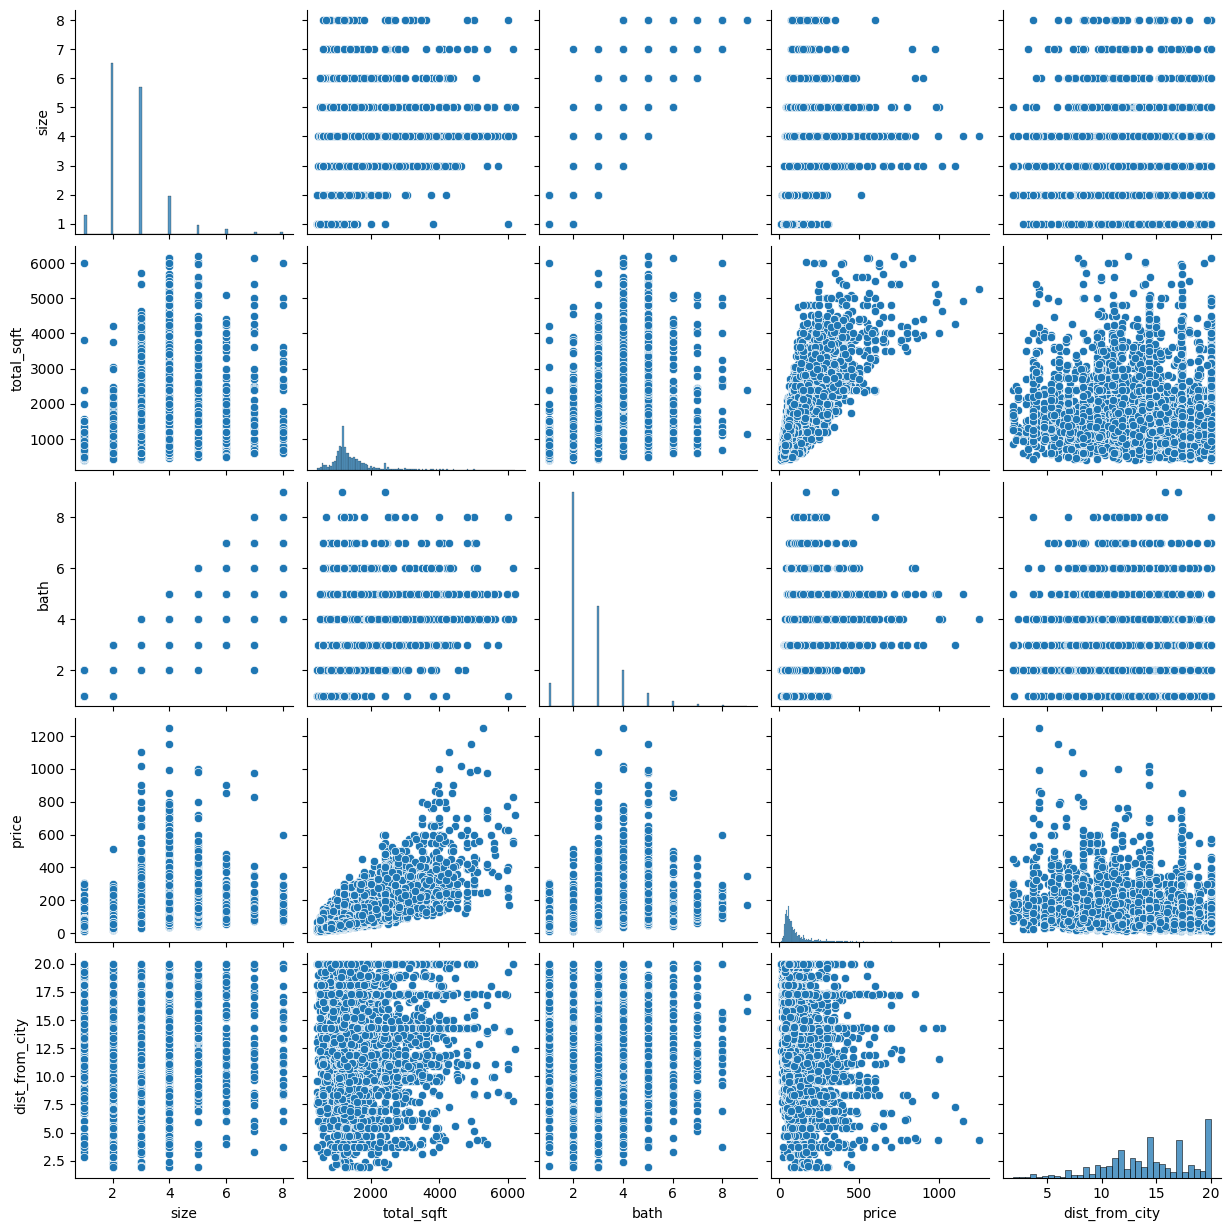

In [82]:
sns.pairplot(train_df_copy)

In [83]:
def outliers(x):
    df = x.copy()
    cols = df.select_dtypes(exclude='object').columns
    for col in cols:
        if col == 'price' or col == 'total_sqft':
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        minimum = Q1 - IQR*1.5
        maximum = Q3 + IQR*1.5
        df.loc[df[col] < minimum, col] = minimum
        df.loc[df[col] > maximum, col] = maximum
    df[['size', 'bath']] = df[['size', 'bath']].astype('int')
    return df

In [84]:
# train_df_copy = outliers(train_df_copy)

In [85]:
# test_df_copy = outliers(test_df_copy)

In [86]:
test_df_copy.shape

(2664, 9)

In [87]:
train_df_copy.shape

(10058, 9)

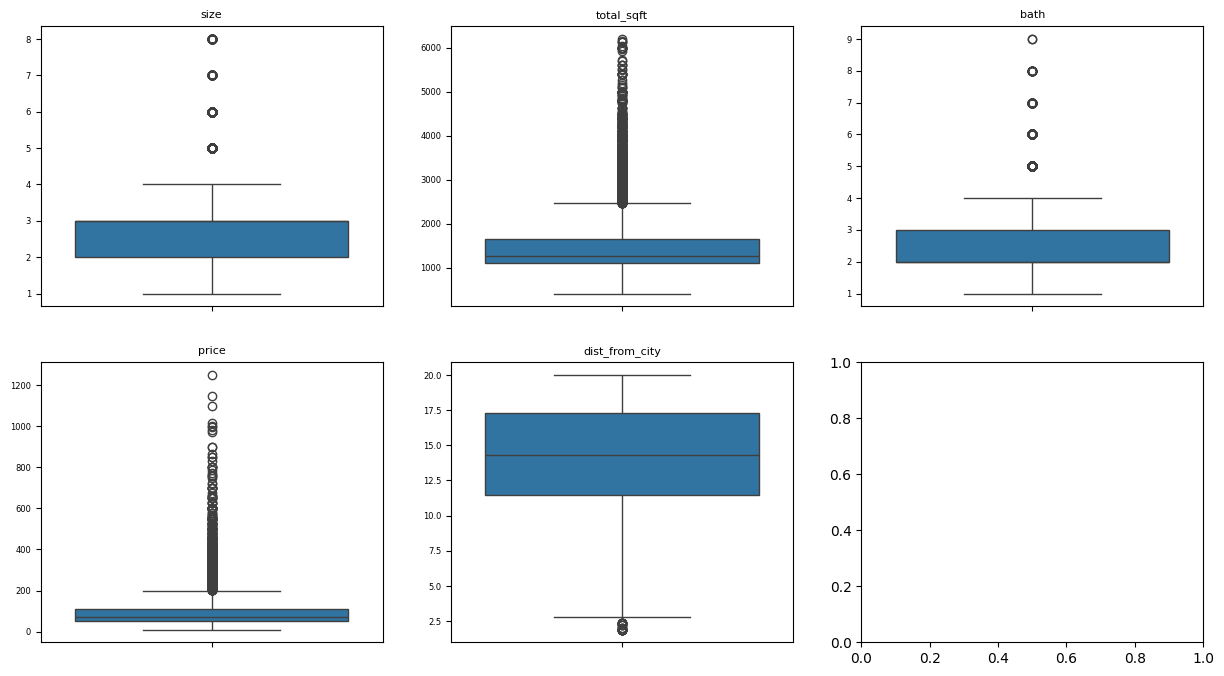

In [88]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(y=num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

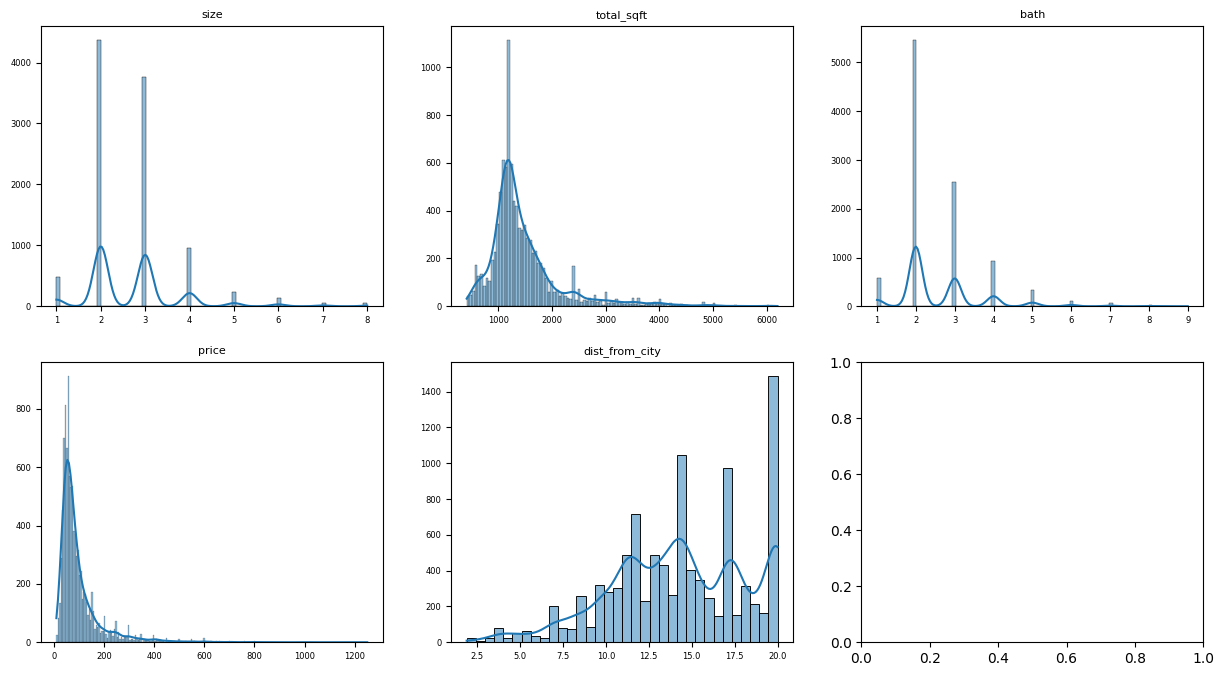

In [89]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

<Axes: xlabel='total_sqft', ylabel='Count'>

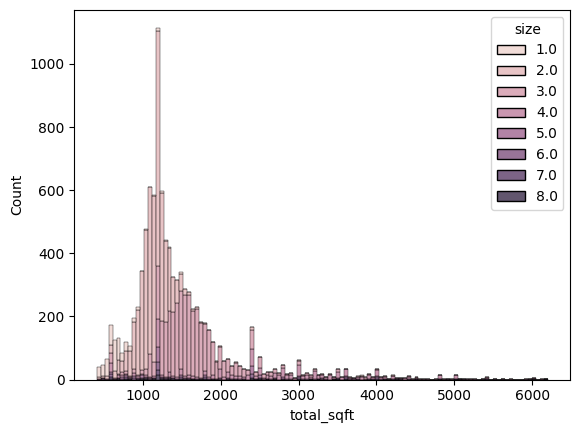

In [90]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack')

In [91]:
train_df_copy['total_sqft'] = np.log1p(train_df_copy['total_sqft'])

In [92]:
test_df_copy['total_sqft'] = np.log1p(test_df_copy['total_sqft'])

<Axes: xlabel='total_sqft', ylabel='Count'>

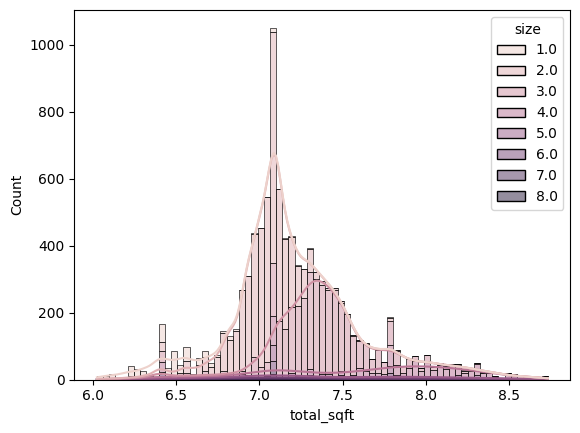

In [93]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack', kde=True)

In [94]:
num_df

,size,total_sqft,bath,price,dist_from_city
0,2.0,1056.0,2.0,39.07,19.3
1,4.0,2600.0,5.0,120.00,20.0
2,3.0,1440.0,2.0,62.00,12.9
3,3.0,1521.0,3.0,95.00,20.0
4,2.0,1200.0,2.0,51.00,11.8
...,...,...,...,...,...
10651,1.0,1200.0,1.0,45.00,14.6
10652,2.0,1260.0,2.0,69.90,15.3
10653,2.0,1092.0,2.0,49.00,13.4
10654,2.0,827.0,2.0,34.00,14.3


In [95]:
test_df_copy.shape

(2664, 9)

In [96]:
tst_ans = pd.read_csv('Datasets/bengaluru_house_prices.csv')

In [97]:
tst_ans.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [98]:
tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'size','total_sqft', 'bath', 'balcony',]).shape

(2664, 2)

In [99]:
test_df_copy.select_dtypes(exclude='object').shape

(2664, 5)

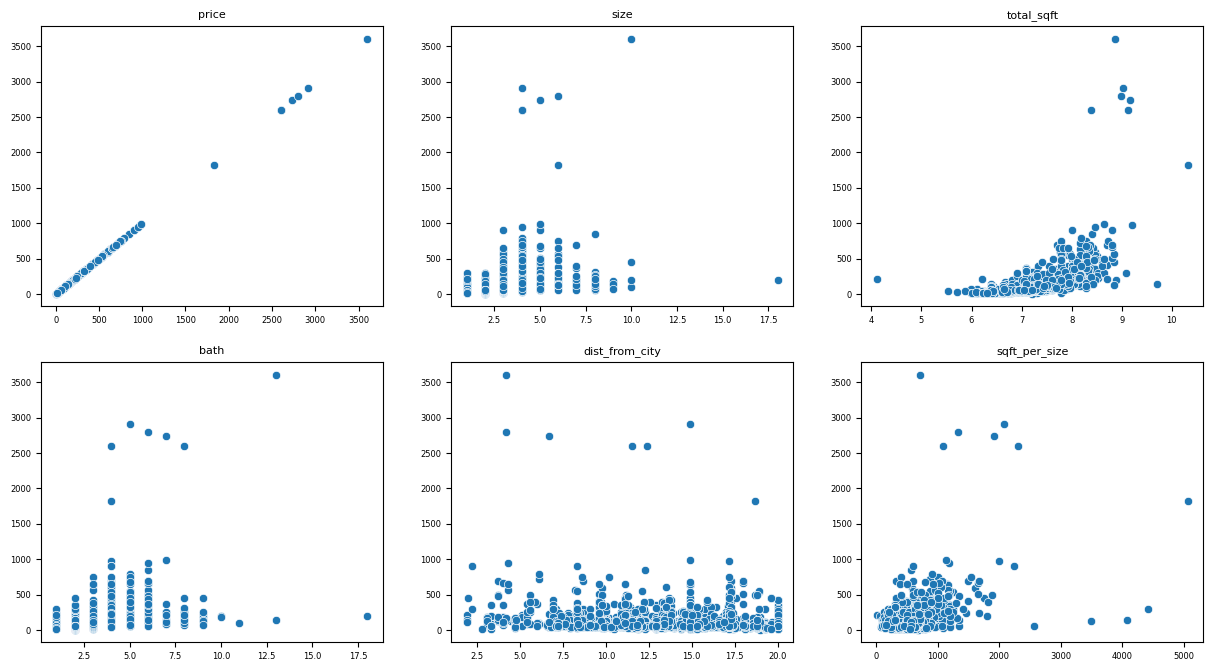

In [100]:
df1 = tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'society', 'size','total_sqft', 'bath', 'balcony']).reset_index(drop=True)
df2 = test_df_copy.select_dtypes(exclude='object').reset_index(drop=True)

num_df = pd.concat([df1, df2], axis=1)

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

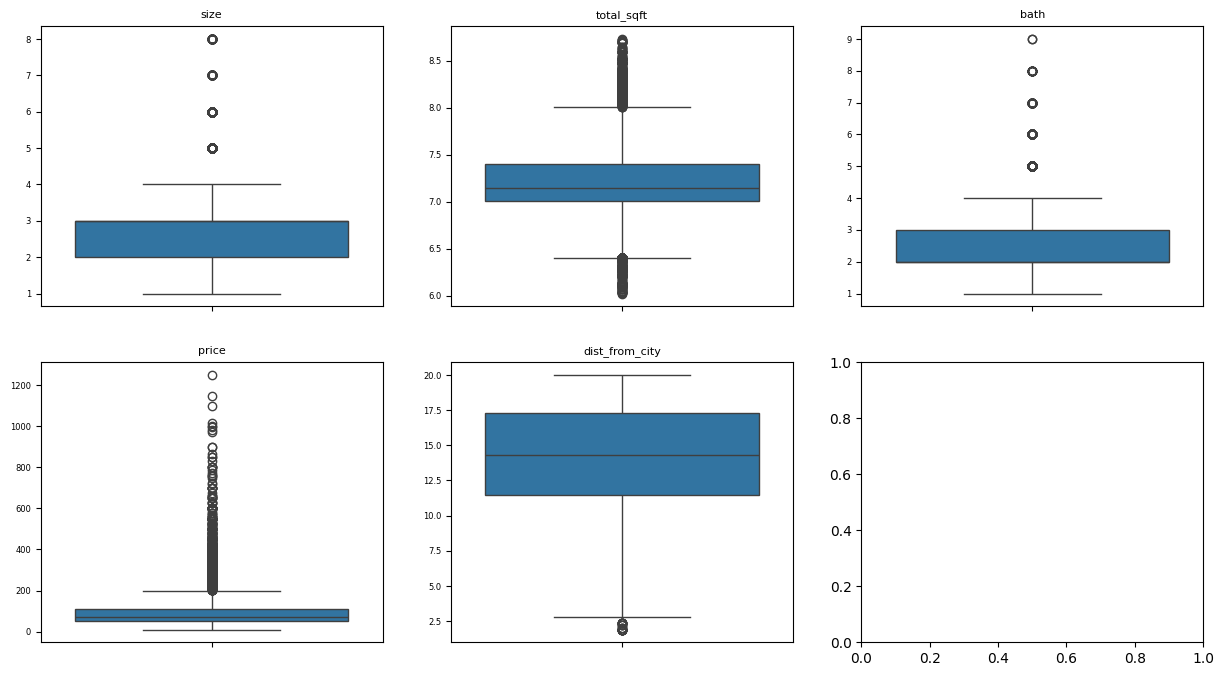

In [101]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [102]:
train_df_copy = train_df_copy[train_df_copy['price'] < 1000]

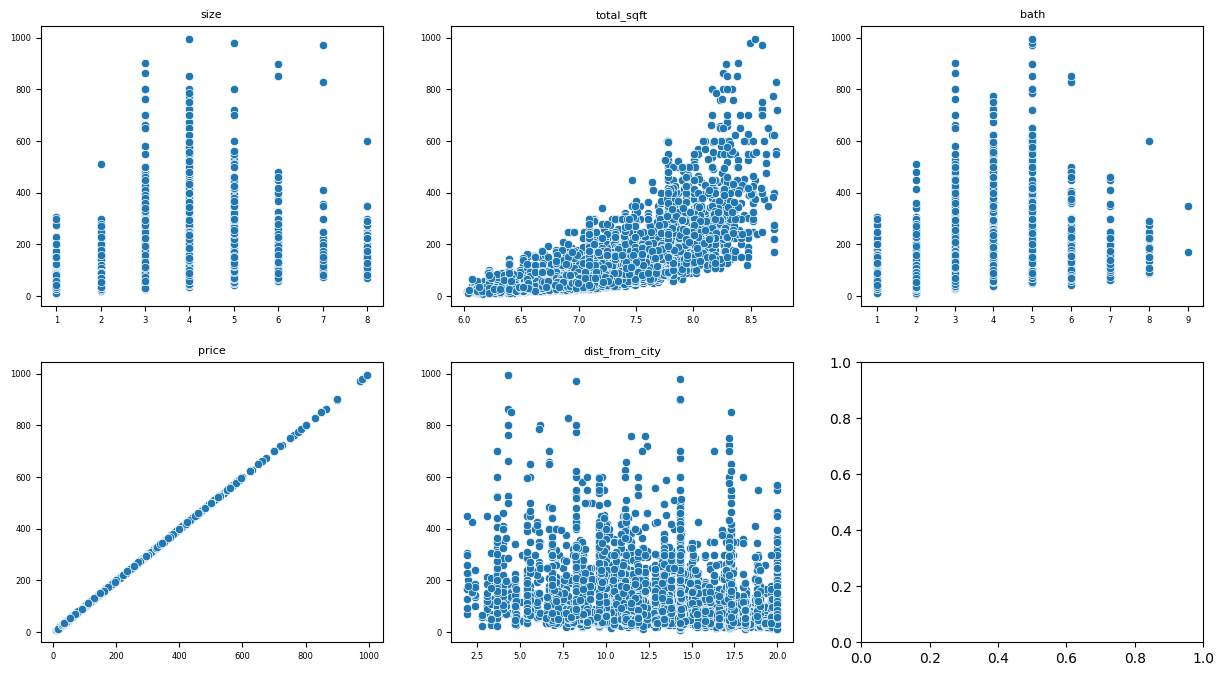

In [103]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

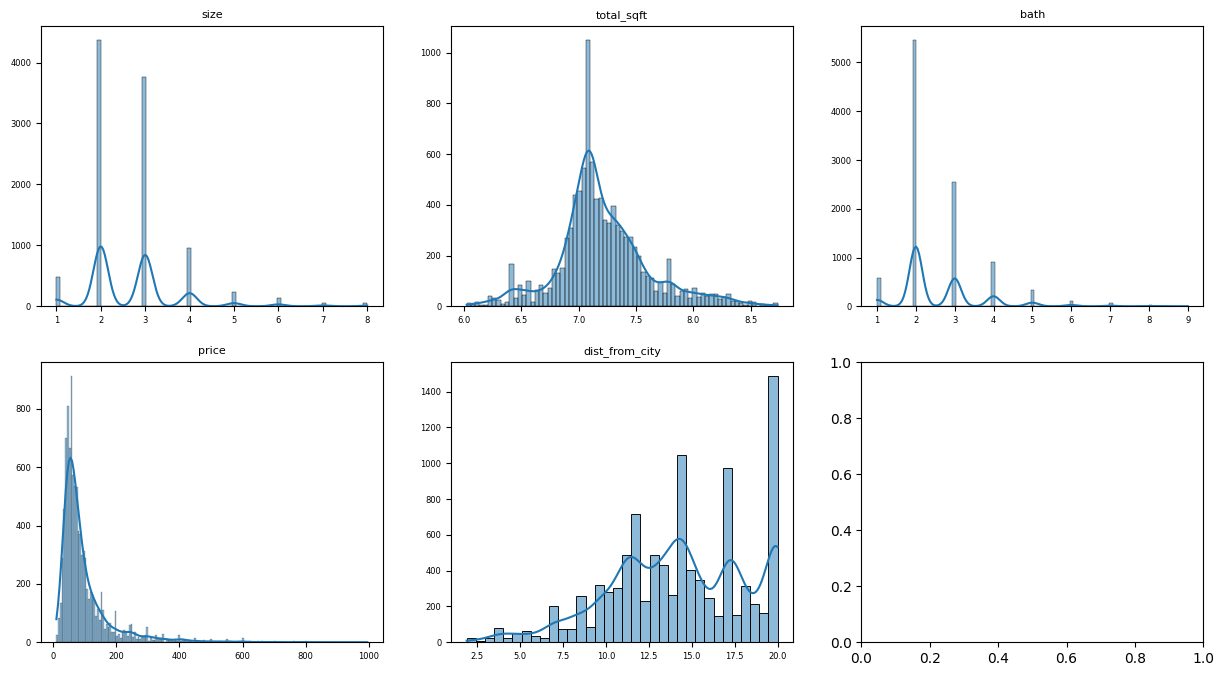

In [104]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [105]:
corr = train_df_copy.corr(numeric_only=True)

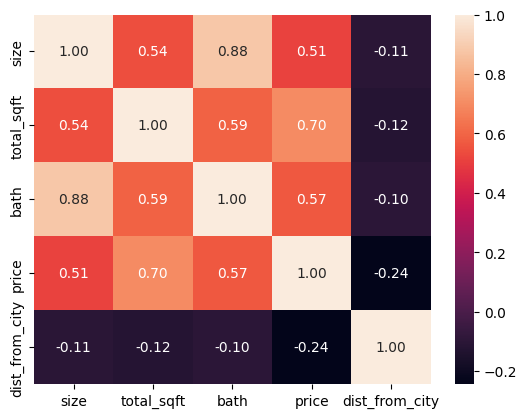

In [106]:
sns.heatmap(corr, annot=True, fmt='0.2f')
plt.show()

In [107]:
train_df_copy

,area_type,location,size,society,total_sqft,bath,price,dist_from_city,area_price_tier
0,Super built-up Area,Electronic City Phase II,2.0,NoSociety,6.963190,2.0,39.07,19.3,low
1,Plot Area,Chikka Tirupathi,4.0,NoSociety,7.863651,5.0,120.00,20.0,mid
2,Built-up Area,Uttarahalli,3.0,NoSociety,7.273093,2.0,62.00,12.9,low
3,Super built-up Area,Lingadheeranahalli,3.0,Soiewre,7.327781,3.0,95.00,20.0,expensive
4,Super built-up Area,Kothanur,2.0,NoSociety,7.090910,2.0,51.00,11.8,mid
...,...,...,...,...,...,...,...,...,...
10651,Plot Area,Parappana Agrahara,1.0,NoSociety,7.090910,1.0,45.00,14.6,low
10652,Super built-up Area,Bhoganhalli,2.0,NoSociety,7.139660,2.0,69.90,15.3,mid
10653,Super built-up Area,Other,2.0,NoSociety,6.996681,2.0,49.00,13.4,mid
10654,Super built-up Area,Other,2.0,NoSociety,6.719013,2.0,34.00,14.3,low


In [108]:
train_df_copy

,area_type,location,size,society,total_sqft,bath,price,dist_from_city,area_price_tier
0,Super built-up Area,Electronic City Phase II,2.0,NoSociety,6.963190,2.0,39.07,19.3,low
1,Plot Area,Chikka Tirupathi,4.0,NoSociety,7.863651,5.0,120.00,20.0,mid
2,Built-up Area,Uttarahalli,3.0,NoSociety,7.273093,2.0,62.00,12.9,low
3,Super built-up Area,Lingadheeranahalli,3.0,Soiewre,7.327781,3.0,95.00,20.0,expensive
4,Super built-up Area,Kothanur,2.0,NoSociety,7.090910,2.0,51.00,11.8,mid
...,...,...,...,...,...,...,...,...,...
10651,Plot Area,Parappana Agrahara,1.0,NoSociety,7.090910,1.0,45.00,14.6,low
10652,Super built-up Area,Bhoganhalli,2.0,NoSociety,7.139660,2.0,69.90,15.3,mid
10653,Super built-up Area,Other,2.0,NoSociety,6.996681,2.0,49.00,13.4,mid
10654,Super built-up Area,Other,2.0,NoSociety,6.719013,2.0,34.00,14.3,low


In [109]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city', 'area_price_tier'],
      dtype='object')

In [110]:
train_df_copy.select_dtypes(exclude='number')

,area_type,location,society,area_price_tier
0,Super built-up Area,Electronic City Phase II,NoSociety,low
1,Plot Area,Chikka Tirupathi,NoSociety,mid
2,Built-up Area,Uttarahalli,NoSociety,low
3,Super built-up Area,Lingadheeranahalli,Soiewre,expensive
4,Super built-up Area,Kothanur,NoSociety,mid
...,...,...,...,...
10651,Plot Area,Parappana Agrahara,NoSociety,low
10652,Super built-up Area,Bhoganhalli,NoSociety,mid
10653,Super built-up Area,Other,NoSociety,mid
10654,Super built-up Area,Other,NoSociety,low


In [111]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))
nrows

2

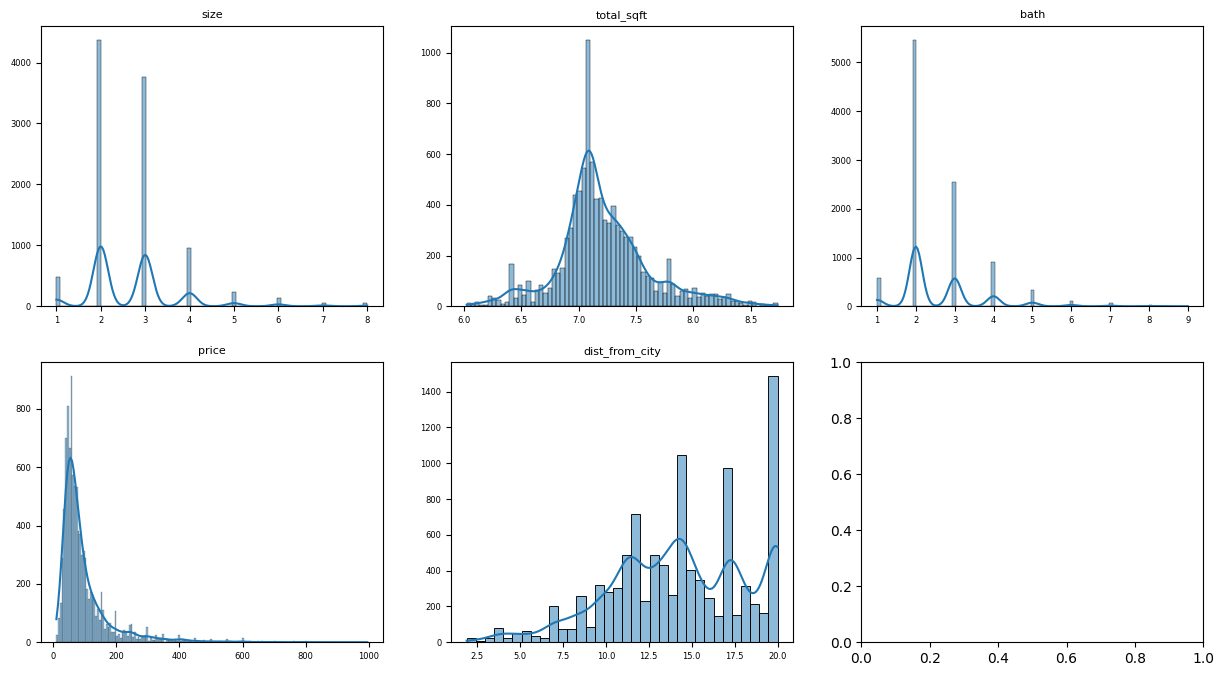

In [112]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [113]:
def scalar_encoder(x):
    df = x.copy()
    scale_col = ['size','bath', 'total_sqft', 'dist_from_city']
    # log_transform = ['total_sqft']
    # df[log_transform] = np.log1p(df[log_transform])

    scalar = StandardScaler()
    df[scale_col] = scalar.fit_transform(df[scale_col])

    df = pd.concat((df, pd.get_dummies(df[['location','area_type', 'society', 'area_price_tier']], sparse=False, dtype='int')), axis=1)
    df.drop(columns=['location', 'society', 'area_type', 'area_price_tier', 'location_Other', 'area_type_Super built-up  Area', 'society_NoSociety', 'area_price_tier_mid'], inplace=True)

    return df

In [114]:
train_df_copy = scalar_encoder(train_df_copy)

In [115]:
test_df_copy = scalar_encoder(test_df_copy)

In [116]:
missing_cols = set(train_df_copy.columns) - set(test_df_copy.columns)
for col in missing_cols:
    test_df_copy[col] = 0

# Ensure same column order
test_df_copy = test_df_copy[train_df_copy.columns]

In [117]:
test_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Balagere,location_Banashankari,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Bellandur,location_Benson Town,...,society_Eladero,society_GMown E,society_GoAirej,society_GrrvaGr,society_IBityin,society_Itelaa,society_JRrnauv,society_Jaades,society_Magiaya,society_MenueNo,society_PhestOn,society_PrarePa,society_Prarkun,society_PrityTr,society_Prityel,society_Prlla C,society_Prncyrn,society_Prtanha,society_Prtates,society_Puachal,society_PualeSk,society_PuandHi,society_PueraRi,society_RInceeg,society_Raard B,society_Rosha I,society_RothaVa,society_SNity S,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa,area_price_tier_expensive,area_price_tier_low
0,-0.661886,-1.721368,-1.311185,0,-1.929967,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0.153308,-0.032544,-0.540274,0,-0.863727,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.153308,0.489591,0.230637,0,0.698437,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,-0.661886,-0.745774,-0.540274,0,0.524864,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,-1.477080,-0.065866,-1.311185,0,-0.566172,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,1.783696,2.062636,1.001547,0,0.698437,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2660,0.968502,2.157143,1.772458,0,-2.202726,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2661,-0.661886,-0.446956,-0.540274,0,0.202512,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2662,0.968502,2.756272,1.001547,0,-0.789338,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [118]:
train_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Balagere,location_Banashankari,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Bellandur,location_Benson Town,...,society_Eladero,society_GMown E,society_GoAirej,society_GrrvaGr,society_IBityin,society_Itelaa,society_JRrnauv,society_Jaades,society_Magiaya,society_MenueNo,society_PhestOn,society_PrarePa,society_Prarkun,society_PrityTr,society_Prityel,society_Prlla C,society_Prncyrn,society_Prtanha,society_Prtates,society_Puachal,society_PualeSk,society_PuandHi,society_PueraRi,society_RInceeg,society_Raard B,society_Rosha I,society_RothaVa,society_SNity S,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa,area_price_tier_expensive,area_price_tier_low
0,-0.676566,-0.620914,-0.548587,39.07,1.256315,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1.259533,1.613918,2.349440,120.00,1.431174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.291484,0.148226,-0.548587,62.00,-0.342395,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0.291484,0.283954,0.417422,95.00,1.431174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,-0.676566,-0.303929,-0.548587,51.00,-0.617173,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10651,-1.644615,-0.303929,-1.514596,45.00,0.082262,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
10652,-0.676566,-0.182936,-0.548587,69.90,0.257121,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10653,-0.676566,-0.537792,-0.548587,49.00,-0.217496,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10654,-0.676566,-1.226930,-0.548587,34.00,0.007323,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [119]:
train_df_copy.drop(columns=['price'])

,size,total_sqft,bath,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Balagere,location_Banashankari,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Bellandur,location_Benson Town,location_Bharathi Nagar,...,society_Eladero,society_GMown E,society_GoAirej,society_GrrvaGr,society_IBityin,society_Itelaa,society_JRrnauv,society_Jaades,society_Magiaya,society_MenueNo,society_PhestOn,society_PrarePa,society_Prarkun,society_PrityTr,society_Prityel,society_Prlla C,society_Prncyrn,society_Prtanha,society_Prtates,society_Puachal,society_PualeSk,society_PuandHi,society_PueraRi,society_RInceeg,society_Raard B,society_Rosha I,society_RothaVa,society_SNity S,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa,area_price_tier_expensive,area_price_tier_low
0,-0.676566,-0.620914,-0.548587,1.256315,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1.259533,1.613918,2.349440,1.431174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.291484,0.148226,-0.548587,-0.342395,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0.291484,0.283954,0.417422,1.431174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,-0.676566,-0.303929,-0.548587,-0.617173,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10651,-1.644615,-0.303929,-1.514596,0.082262,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
10652,-0.676566,-0.182936,-0.548587,0.257121,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10653,-0.676566,-0.537792,-0.548587,-0.217496,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10654,-0.676566,-1.226930,-0.548587,0.007323,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [120]:
X = train_df_copy.drop(columns=['price'])
y = np.log1p(train_df_copy['price'])
train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=0.8, random_state=42)

In [121]:
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(8042, 262) (2011, 262) (8042,) (2011,)


In [122]:
lin_model = LinearRegression()
lin_model.fit(train_x,train_y)


LinearRegression()

In [123]:
lin_model.score(train_x, train_y)

0.8376910776930752

In [124]:
lin_model.score(test_x, test_y)

0.8149316781753431

In [125]:
lin_model.predict(test_df_copy.drop(columns='price'))

array([4.27523172, 4.3214701 , 4.4794472 , ..., 3.96593554, 5.58784001,
       3.02583964])

In [126]:
prc = tst_ans.iloc[10656:]['price']

In [127]:
prc

10656     40.00
10657     54.79
10658    106.00
10659     70.00
10660     55.00
          ...  
13315    231.00
13316    400.00
13317     60.00
13318    488.00
13319     17.00
Name: price, Length: 2664, dtype: float64

In [128]:
test_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Balagere,location_Banashankari,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Bellandur,location_Benson Town,...,society_Eladero,society_GMown E,society_GoAirej,society_GrrvaGr,society_IBityin,society_Itelaa,society_JRrnauv,society_Jaades,society_Magiaya,society_MenueNo,society_PhestOn,society_PrarePa,society_Prarkun,society_PrityTr,society_Prityel,society_Prlla C,society_Prncyrn,society_Prtanha,society_Prtates,society_Puachal,society_PualeSk,society_PuandHi,society_PueraRi,society_RInceeg,society_Raard B,society_Rosha I,society_RothaVa,society_SNity S,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa,area_price_tier_expensive,area_price_tier_low
0,-0.661886,-1.721368,-1.311185,0,-1.929967,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0.153308,-0.032544,-0.540274,0,-0.863727,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.153308,0.489591,0.230637,0,0.698437,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,-0.661886,-0.745774,-0.540274,0,0.524864,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,-1.477080,-0.065866,-1.311185,0,-0.566172,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,1.783696,2.062636,1.001547,0,0.698437,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2660,0.968502,2.157143,1.772458,0,-2.202726,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2661,-0.661886,-0.446956,-0.540274,0,0.202512,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2662,0.968502,2.756272,1.001547,0,-0.789338,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [129]:
lin_model.score(test_df_copy.drop(columns='price'), np.log1p(prc))

0.7797015469377323

In [130]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) # ShuffleSplit - Randomize the sample

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.81756837, 0.83677691, 0.82120972, 0.83654377, 0.81386083])

In [131]:
features_combined_train_const = sm.add_constant(train_x)
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     153.8
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:17:40   Log-Likelihood:                -605.22
No. Observations:                8042   AIC:                             1734.
Df Residuals:                    7780   BIC:                             3566.
Df Model:                         261                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

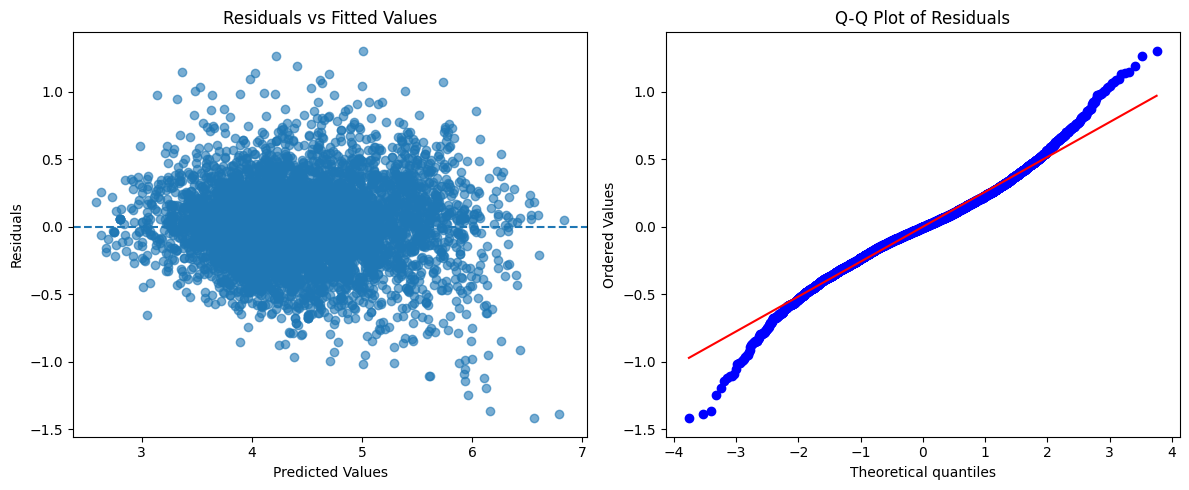

In [132]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [133]:
features_to_keep = train_x.columns.to_list()
while True:
    model = sm.OLS(train_y, sm.add_constant(train_x[features_to_keep])).fit()
    p_values = model.pvalues.drop('const')
    max_p_value = p_values.max()

    if max_p_value > 0.5:
        # Remove the least significant feature
        feature_to_remove = p_values.idxmax()
        features_to_keep.remove(feature_to_remove)
    else:
        # Stop when all remaining features are significant
        break
print(features_to_keep)

['size', 'total_sqft', 'bath', 'dist_from_city', 'location_2nd Stage Nagarbhavi', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Anandapura', 'location_Ananth Nagar', 'location_Anekal', 'location_Anjanapura', 'location_Ardendale', 'location_Arekere', 'location_Attibele', 'location_BTM 2nd Stage', 'location_BTM Layout', 'location_Babusapalaya', 'location_Banashankari', 'location_Banaswadi', 'location_Bannerghatta', 'location_Bannerghatta Road', 'location_Basavangudi', 'location_Basaveshwara Nagar', 'location_Battarahalli', 'location_Begur', 'location_Bellandur', 'location_Bhoganhalli', 'location_Bommanahalli', 'location_Bommasandra', 'location_Bommenahalli', 'location_Brookefield', 'location_Byrasandra', 'location_CV Raman Nagar', 'location_Chamrajpet', 'location_Chandapura', 'location_Chikka Tirupathi', 'location_Choodasandra', 'location_Cooke Town', 'location_Cox Town', 'location_C

In [134]:
len(features_to_keep)

213

In [135]:
features_combined_train_const = sm.add_constant(train_x[features_to_keep])
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     189.5
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:17:47   Log-Likelihood:                -609.00
No. Observations:                8042   AIC:                             1646.
Df Residuals:                    7828   BIC:                             3142.
Df Model:                         213                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

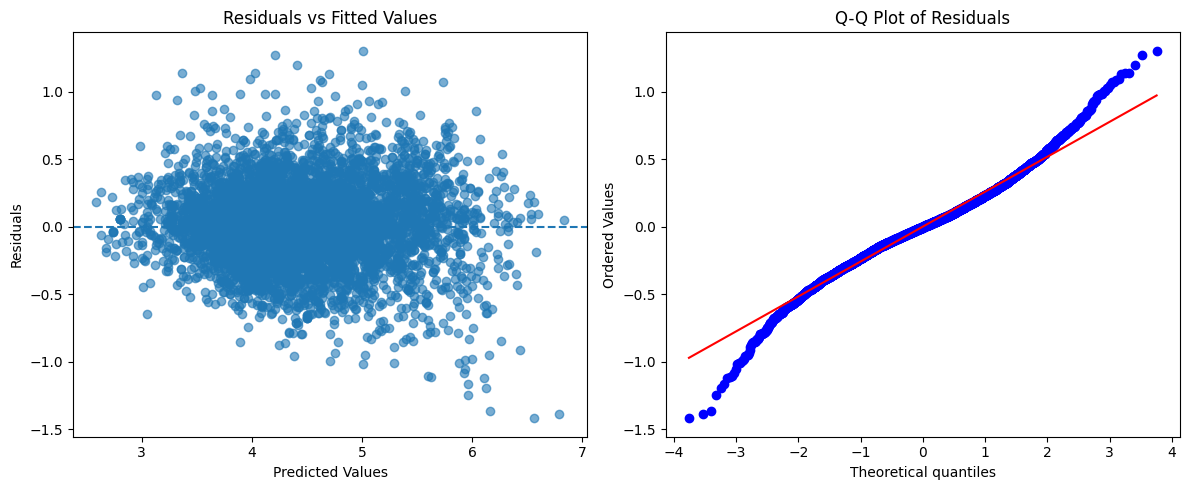

In [136]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [137]:
corr = train_df_copy.corr().abs()

high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))\
                .stack()\
                .sort_values(ascending=False)

high_corr[high_corr > 0.85]


location_Lingadheeranahalli  society_Soiewre    1.000000
location_Bisuvanahalli       society_Prityel    0.987974
location_Budigere            society_PrityTr    0.986705
location_Balagere            society_Soresea    0.917388
location_Thigalarapalya      society_Prtanha    0.886819
size                         bath               0.878774
dtype: float64

In [138]:
print(train_df_copy.corr(numeric_only=True).abs()['price'][[item[0] for item in high_corr[high_corr > 0.85].index.to_list()]])

location_Lingadheeranahalli    0.005373
location_Bisuvanahalli         0.041350
location_Budigere              0.021429
location_Balagere              0.026553
location_Thigalarapalya        0.027173
size                           0.510518
Name: price, dtype: float64


In [139]:
print(train_df_copy.corr(numeric_only=True).abs()['price'][[item[1] for item in high_corr[high_corr > 0.85].index.to_list()]])

society_Soiewre    0.005373
society_Prityel    0.040935
society_PrityTr    0.020500
society_Soresea    0.024921
society_Prtanha    0.032150
bath               0.565464
Name: price, dtype: float64


In [140]:
second_features = [item[1] for item in high_corr[high_corr > 0.85].index.to_list()]
print(second_features)

['society_Soiewre', 'society_Prityel', 'society_PrityTr', 'society_Soresea', 'society_Prtanha', 'bath']


In [141]:
features_to_keep = list(set(train_x.columns) - set(['location_Lingadheeranahalli', 'society_Prityel','society_PrityTr', 'society_Soresea', 'location_Thigalarapalya']) - {'size'})

In [142]:
model = LinearRegression()
model.fit(train_x[features_to_keep],train_y)

LinearRegression()

In [143]:
model.score(test_x[features_to_keep], test_y)

0.8157235413837123

In [144]:
model.predict(train_x[features_to_keep])

array([3.88132616, 3.28400632, 4.05214879, ..., 5.1825806 , 3.32542618,
       4.91915637])

In [145]:
model.score(test_df_copy[features_to_keep], np.log1p(prc))

0.7800829206371187

In [146]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_values = []

    for col in df.columns:
        X = df.drop(columns=[col])
        y = df[col]

        model = LinearRegression().fit(X, y)
        r2 = model.score(X, y)
        if r2 == 1:
            vif = float("inf")
        else:
            vif = 1 / (1 - r2)
        vif_values.append(vif)

    vif_data["VIF"] = vif_values
    return vif_data

In [156]:
pipeline_model = Pipeline(steps=[
    ('model', LinearRegression()),
])

In [ ]:
params = [
    {'model' : [Lasso()],
    "model__alpha": [0.00005, 0.00001, 0.0001],
    "model__fit_intercept": [True, False],
    "model__selection": ["cyclic", "random"]
    },
    {'model' : [Ridge()],
    "model__alpha": [0.1, 0.8, 1, 2, 3, 5, 10],
    "model__fit_intercept": [True, False],
    "model__solver": ["auto","sag", "saga",'cholesky']
     }
]

In [160]:
final_model = GridSearchCV(pipeline_model, params , cv=5, scoring='neg_mean_squared_error')

In [161]:
final_model.fit(train_x[features_to_keep],train_y)
print(final_model.best_params_)
print(final_model.best_score_)

{'model': Ridge(), 'model__alpha': 2, 'model__fit_intercept': True, 'model__solver': 'auto'}
-0.07216362116292464


In [150]:
s

NameError: name 's' is not defined

In [ ]:
ridge_params = {
    "alpha": [0.1, 0.8, 1, 2, 3, 5, 10],
    "fit_intercept": [True, False],
    "solver": ["auto","sag", "saga"]
}

In [ ]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
gs_rid = GridSearchCV(Ridge(), ridge_params , cv=cv, return_train_score=False)
gs_rid.fit(train_x[features_to_keep],train_y)
print(gs_rid.best_params_)
print(gs_rid.best_score_)

{'alpha': 2, 'fit_intercept': True, 'solver': 'auto'}
0.823981853532415


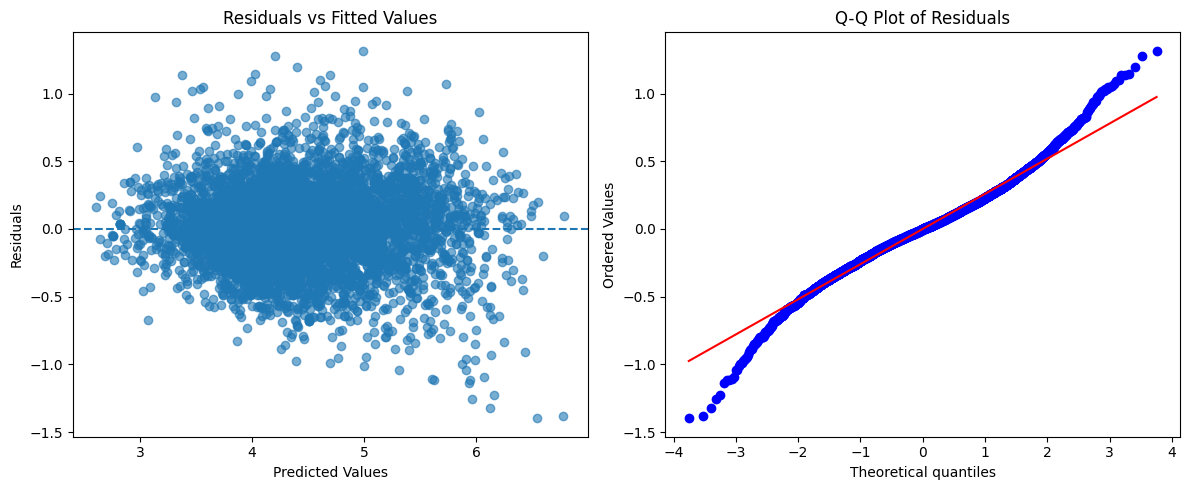

In [ ]:
y_pred = gs_rid.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

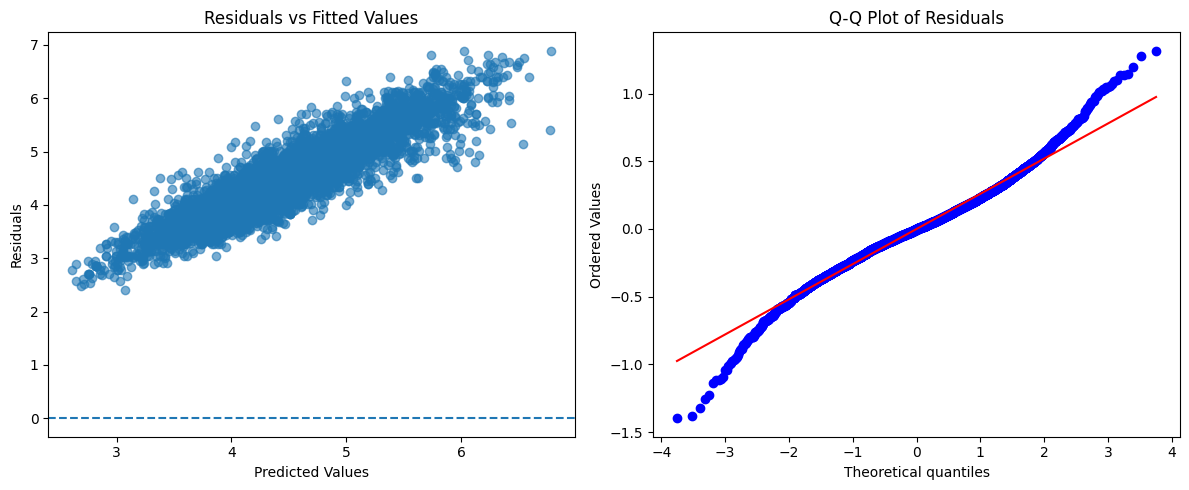

In [ ]:
y_pred = gs_rid.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, train_y, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
lasso_params = {
    "alpha": [0.00005, 0.00001, 0.0001],
    "fit_intercept": [True, False],
    "selection": ["cyclic", "random"]
}

In [ ]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
gs_las = GridSearchCV(Lasso(), lasso_params , cv=cv, return_train_score=False)
gs_las.fit(train_x[features_to_keep],train_y)
print(gs_las.best_params_)
print(gs_las.best_score_)

{'alpha': 5e-05, 'fit_intercept': True, 'selection': 'random'}
0.8239031047640358


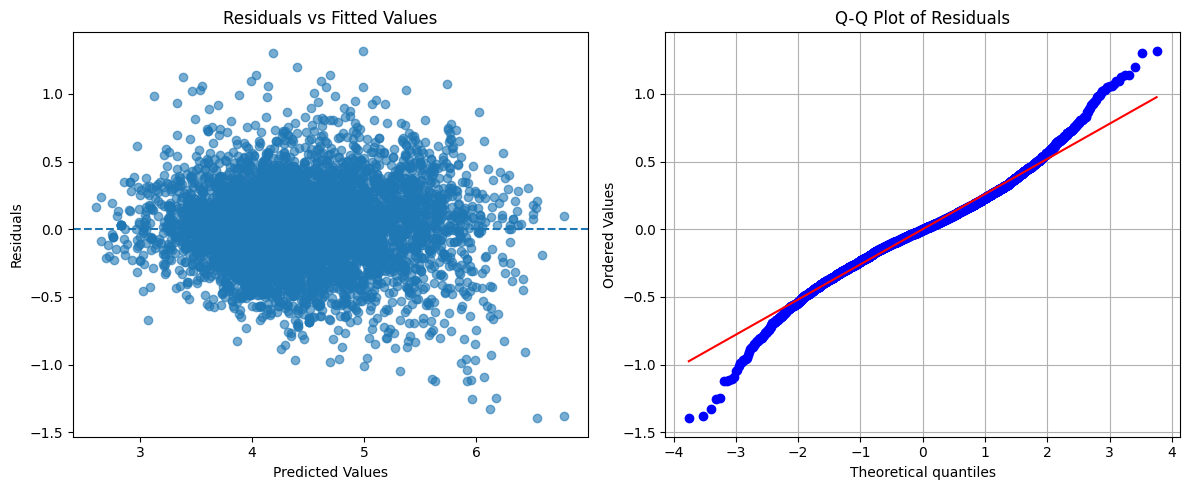

In [ ]:
y_pred = gs_las.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
y_pred = gs_las.predict(train_x[features_to_keep])
residuals = train_y - y_pred

residuals[residuals.abs() > 1]

6506   -1.038903
7035    1.139615
2237   -1.107960
4642    1.027094
4293    1.009564
8438    1.092929
9006   -1.009082
8030   -1.088467
9151    1.051516
2338    1.318547
7207   -1.245102
1212   -1.120141
9512    1.050778
4494    1.026536
2240   -1.256095
4629    1.022290
2368   -1.397115
2310    1.200757
7836    1.054844
5304    1.300092
7104   -1.380422
5913   -1.124612
8688    1.094587
4343   -1.045370
7667   -1.116004
4061    1.061241
601     1.128030
5510    1.070579
3998   -1.325296
3651    1.137059
Name: price, dtype: float64

In [ ]:
train_df['price'].describe()

count    10656.000000
mean       112.214256
std        142.231967
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       2700.000000
Name: price, dtype: float64

In [162]:
final_model.score(test_df_copy[features_to_keep], np.log1p(prc))

-0.1117682786290709

In [163]:
pred = final_model.predict(test_df_copy[features_to_keep])

In [ ]:
np.expm1(pred)

array([ 65.55783789,  74.12935993,  87.12627903, ...,  51.58694528,
       265.35072661,  19.75500438])

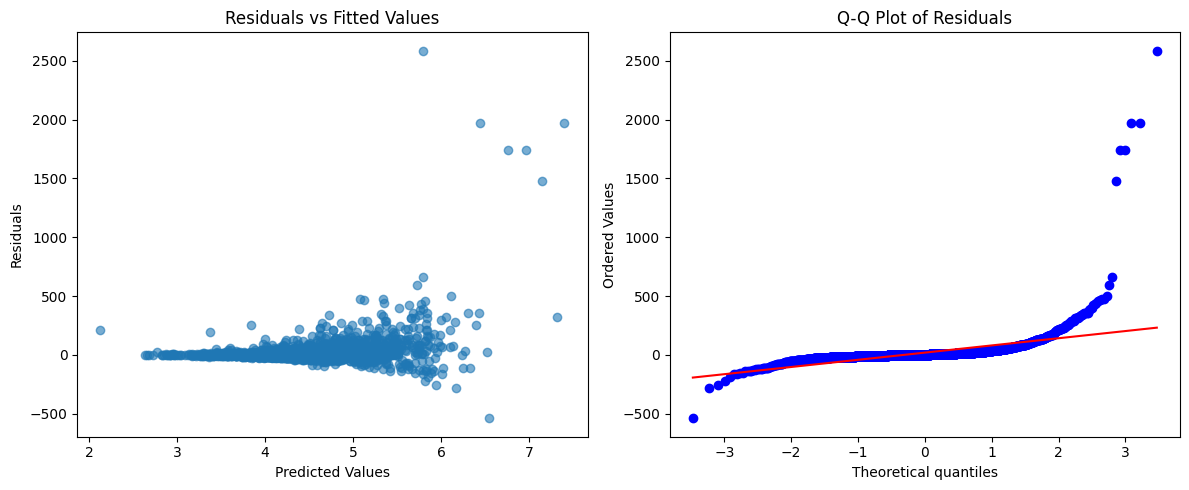

In [ ]:
y_pred = np.expm1(pred)
residuals = prc - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(pred, residuals, alpha=0.6)
# plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

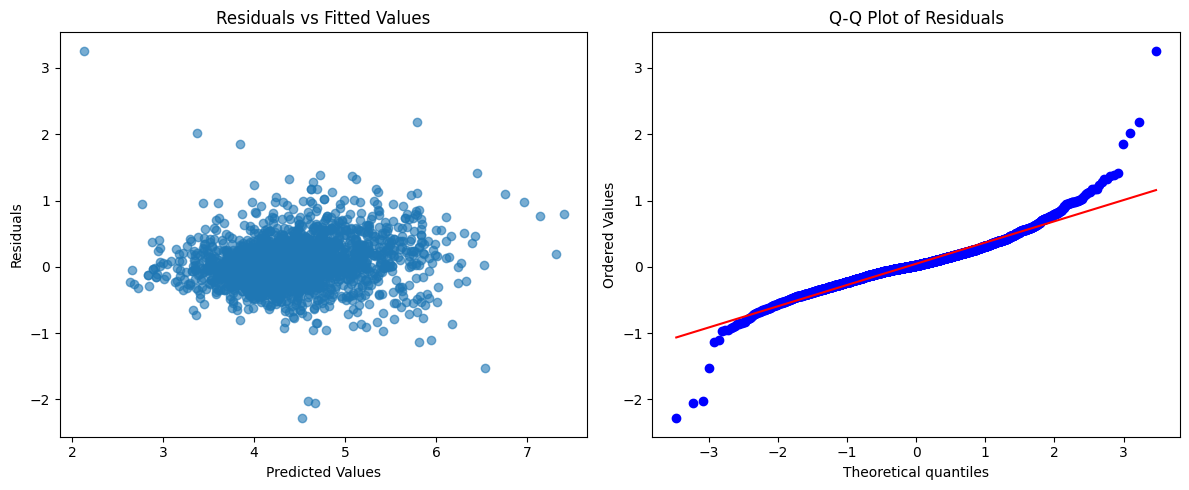

In [ ]:
y_pred = pred
residuals = np.log1p(prc) - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(pred, residuals, alpha=0.6)
# plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
residuals

10656   -0.484499
10657   -0.297617
10658    0.194058
10659    0.218900
10660   -0.329119
           ...   
13315    0.282146
13316    0.221559
13317    0.148406
13318    0.607549
13319   -0.142416
Name: price, Length: 2664, dtype: float64

In [ ]:
y_pred

array([4.19807131, 4.31921143, 4.47877077, ..., 3.9624679 , 5.58481396,
       3.03278739])

In [ ]:
[13319 - 10656]

[2663]

In [ ]:
y_pred = np.expm1(pred)
residuals = prc - y_pred
residuals[residuals > 500]

11080    2585.282106
11763    1473.910353
12164     594.688445
12443    1972.495559
13067    1969.414795
13086     662.495646
13197    1740.396876
13200    1742.724328
Name: price, dtype: float64

In [ ]:
residuals[residuals > 500].index

Index([11080, 11763, 12164, 12443, 13067, 13086, 13197, 13200], dtype='int64')

In [ ]:
np.array([100, 200, 300])

array([100, 200, 300])

In [ ]:
list(np.array([100, 200, 300]) - np.array([100]))

[0, 100, 200]

In [ ]:
high_residual_labels = residuals[residuals.abs() > 200].index.to_numpy() - np.array([10656])

df_final = test_df[test_df.ID.isin(high_residual_labels)].copy()

df_final['price_original'] = prc.iloc[high_residual_labels].values
df_final['predicted_price'] = y_pred[high_residual_labels]
df_final['residual_error'] = residuals.iloc[high_residual_labels].values

df_final

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price_original,predicted_price,residual_error
25,25,Super built-up Area,20-Apr,Viviani Road,3 BHK,NaN,2214,3.0,2.0,350.0,107.832783,242.167217
28,28,Plot Area,Ready To Move,Giri Nagar,4 Bedroom,NaN,4000,3.0,2.0,750.0,470.696466,279.303534
51,51,Plot Area,Ready To Move,Whitefield,3 Bedroom,Toindls,4800,4.0,2.0,600.0,339.889118,260.110882
93,93,Plot Area,Ready To Move,Sarjapur Road,5 Bedroom,AdlasRe,10000,4.0,2.0,975.0,615.778578,359.221422
104,104,Built-up Area,Ready To Move,Hebbal,4 Bedroom,NaN,3758,4.0,2.0,450.0,229.745724,220.254276
...,...,...,...,...,...,...,...,...,...,...,...,...
2591,2591,Plot Area,Ready To Move,5th Stage BEML Layout,4 Bedroom,NaN,1200,5.0,NaN,325.0,116.375686,208.624314
2605,2605,Plot Area,Ready To Move,Havanur extension,3 Bedroom,NaN,2000,2.0,2.0,360.0,138.455690,221.544310
2634,2634,Super built-up Area,Ready To Move,Sarjapur Road,4 BHK,Maana E,4050,2.0,1.0,450.0,162.605905,287.394095
2650,2650,Plot Area,Ready To Move,Rajarajeshwari Nagara,4 Bedroom,NaN,1200,5.0,NaN,325.0,100.413764,224.586236


<Axes: xlabel='price', ylabel='Count'>

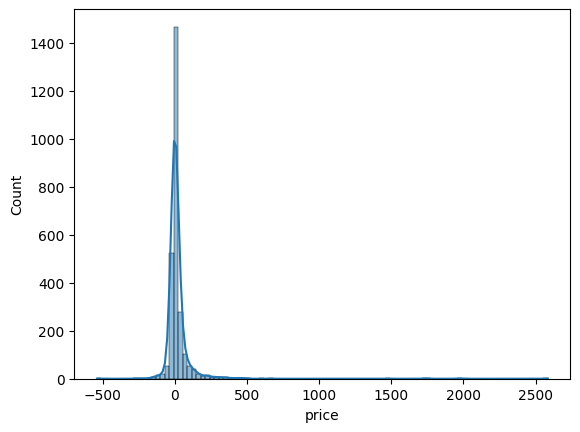

In [ ]:
sns.histplot(residuals, bins = 100, kde=True)

<Axes: ylabel='price'>

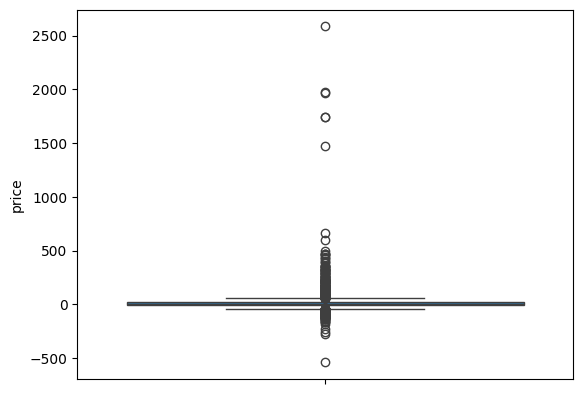

In [ ]:
sns.boxplot(residuals)

In [ ]:
type(high_residual_labels)

numpy.ndarray

In [ ]:
prc.iloc[11080 - 10656]

2912.0

In [ ]:
prc.iloc[high_residual_labels].values

array([ 350.,  750.,  600.,  975.,  450.,  852.,  630.,  125., 2912.,
        650.,  700.,  630.,  200.,  107.,  716.,  788.,  400.,  460.,
        400.,  550.,  218.,  699.,  602.,  500., 2736.,  375.,  601.,
        500.,  550.,  900.,  400.,  550.,  340.,  610.,  900.,  700.,
        470.,  500., 2600.,  700.,  750.,  149.,  295.,  660.,  530.,
        425.,  744.,  400.,  650.,  948.,  650.,  540.,  649.,  325.,
        300.,  680.,  450., 1824.,  500., 3600.,  988.,  660.,  536.,
       2600., 2800.,  325.,  325.,  360.,  450.,  325.,  488.])

In [ ]:
prc.iloc[high_residual_labels]

10681    350.0
10684    750.0
10707    600.0
10749    975.0
10760    450.0
         ...  
13247    325.0
13261    360.0
13290    450.0
13306    325.0
13318    488.0
Name: price, Length: 71, dtype: float64

In [ ]:
y_pred[high_residual_labels]

array([ 107.83278255,  470.69646577,  339.88911767,  615.77857755,
        229.74572426,  595.7686806 ,  165.90282294,  378.27352994,
        326.71789413,  310.60814495,  317.02650984,  159.47384744,
        478.11777187,  332.76204689,  325.89722204,  334.0646364 ,
        175.98564278,  173.14993294,  144.7515126 ,  339.88911767,
          7.40155499,  400.12518011,  286.57231204,  212.12667947,
       1262.08964695,  103.48461176,  285.90103389,  213.53658291,
        201.78427473,  543.41457461,  127.79609068,  340.16242667,
        138.36987823,  297.51484062,  305.31155477,  279.98035838,
        213.53658291,  250.75983109,  627.50444075,  341.12504637,
        320.93918265,  689.00677892,   45.67629851,  342.73436374,
        291.4880963 ,  197.61274856,  425.11089138,  194.91758127,
        291.06393223,  449.60286452,  249.71231407,  313.94421238,
        210.58049841,  116.37568644,   79.43749289,  207.98765131,
        111.30208667, 1502.78359169,  276.2496139 , 1630.58520

In [ ]:
residuals.iloc[11080 - 10656]

2585.2821058703857

In [ ]:
test_df[test_df.ID == (11080 - 10656)]

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
424,424,Super built-up Area,18-Jan,Ashok Nagar,4 BHK,NaN,8321,5.0,2.0


In [ ]:
test_df.iloc[11080 - 10656]

ID                               424
area_type       Super built-up  Area
availability                  18-Jan
location                 Ashok Nagar
size                           4 BHK
society                          NaN
total_sqft                      8321
bath                             5.0
balcony                          2.0
Name: 424, dtype: object

In [164]:
np.sqrt(mean_squared_error(prc, np.expm1(pred)))

112.07154204840975

In [ ]:
np.sqrt(mean_squared_error(np.log1p(prc), pred))

0.33431763134640513

In [ ]:
gs_las.score(test_df_copy[features_to_keep], np.log1p(prc))

0.7797302474330062

In [ ]:
pred_gs_las = np.expm1(gs_las.predict(test_df_copy[features_to_keep]))

In [ ]:
np.sqrt(mean_squared_error(prc, pred_gs_las))

112.39909448441337